# Miscellaneous Results and Figures from:
## Entanglement generation and characterization using metamaterial resonators

Alessandro S. Santana

In [3]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MaxNLocator, FixedLocator, FixedFormatter, FuncFormatter
from IPython.display import clear_output
from numpy import *
from qutip import *
from IPython.display import Image
from numpy.linalg import *
import multiprocessing  
from multiprocessing import Pool, cpu_count
import scipy.constants as sc
import time
import datetime
import os
import glob
from matplotlib import cm
import matplotlib as mpl

ls = 30.0   # tick label size
fs = 30.0   # axis label size

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    # ===== Fonts =====
    "font.size": 30,
    "axes.labelsize": fs,
    "axes.titlesize": 30,
    # ===== Lines =====
    "lines.linewidth": 2.5,
    # ===== Ticks =====
    "xtick.labelsize": ls,
    "ytick.labelsize": ls,
    "xtick.direction": "in",  
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    # Tick size 
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    # ===== Axes =====
    "axes.linewidth": 2.5,
    "axes.grid": False, 
    # ===== Legend =====
    "legend.frameon": False,
    "legend.fontsize": 15,
    # ===== Figure =====
    "figure.figsize": (16, 6),
    "figure.dpi": 100
})

saveResults = True


def load_result(folder):
    #files = glob.glob(os.path.join(folder, "Results_*.npy"))
    files = glob.glob(os.path.join(folder, "*.npy"))
    
    if not files:
        raise FileNotFoundError("No result files found.")
    
    # Sort by modification time (newest first)
    files_sorted = sorted(files, key=os.path.getmtime, reverse=True)
    
    print("\nAvailable files:")
    for i, f in enumerate(files_sorted):
        print(f"[{i}] {os.path.basename(f)}")
    
    choice = input("\nLoad most recent file? (y/n): ").strip().lower()

    if choice in ['', 'y']:
        selected_file = files_sorted[0]
    else:
        idx = int(input("Enter file index: "))
        if idx < 0 or idx >= len(files_sorted):
            raise ValueError("Invalid index.")
        selected_file = files_sorted[idx]
    
    print(f"\nLoading: {selected_file}\n")
    
    return load(selected_file, allow_pickle=True)

def save_figure(fig, folder, name, formats=("pdf", "png"), time_stamp=True, dpi=300):
    
    choice = input("\nSave figure? (y/N): ").strip().lower()
    if choice not in ['y', 'yes']:
        print("Figure not saved.")
        return
    
    os.makedirs(folder, exist_ok=True)
    
    if time_stamp:
        time_str = datetime.datetime.now().strftime("_[%Y-%m-%d]_[%Hh%Mm]")
    else:
        time_str = ""
    
    base_path = os.path.join(folder, name + time_str)
    
    saved_files = []
    
    for fmt in formats:
        fmt = fmt.lower()
        
        if fmt == "png":
            fig.savefig(base_path + ".png", dpi=dpi, bbox_inches='tight')
        else:
            fig.savefig(base_path + f".{fmt}", bbox_inches='tight')
        
        saved_files.append(base_path + f".{fmt}")
    
    print("\nSaved:")
    for f in saved_files:
        print(f)

## Model

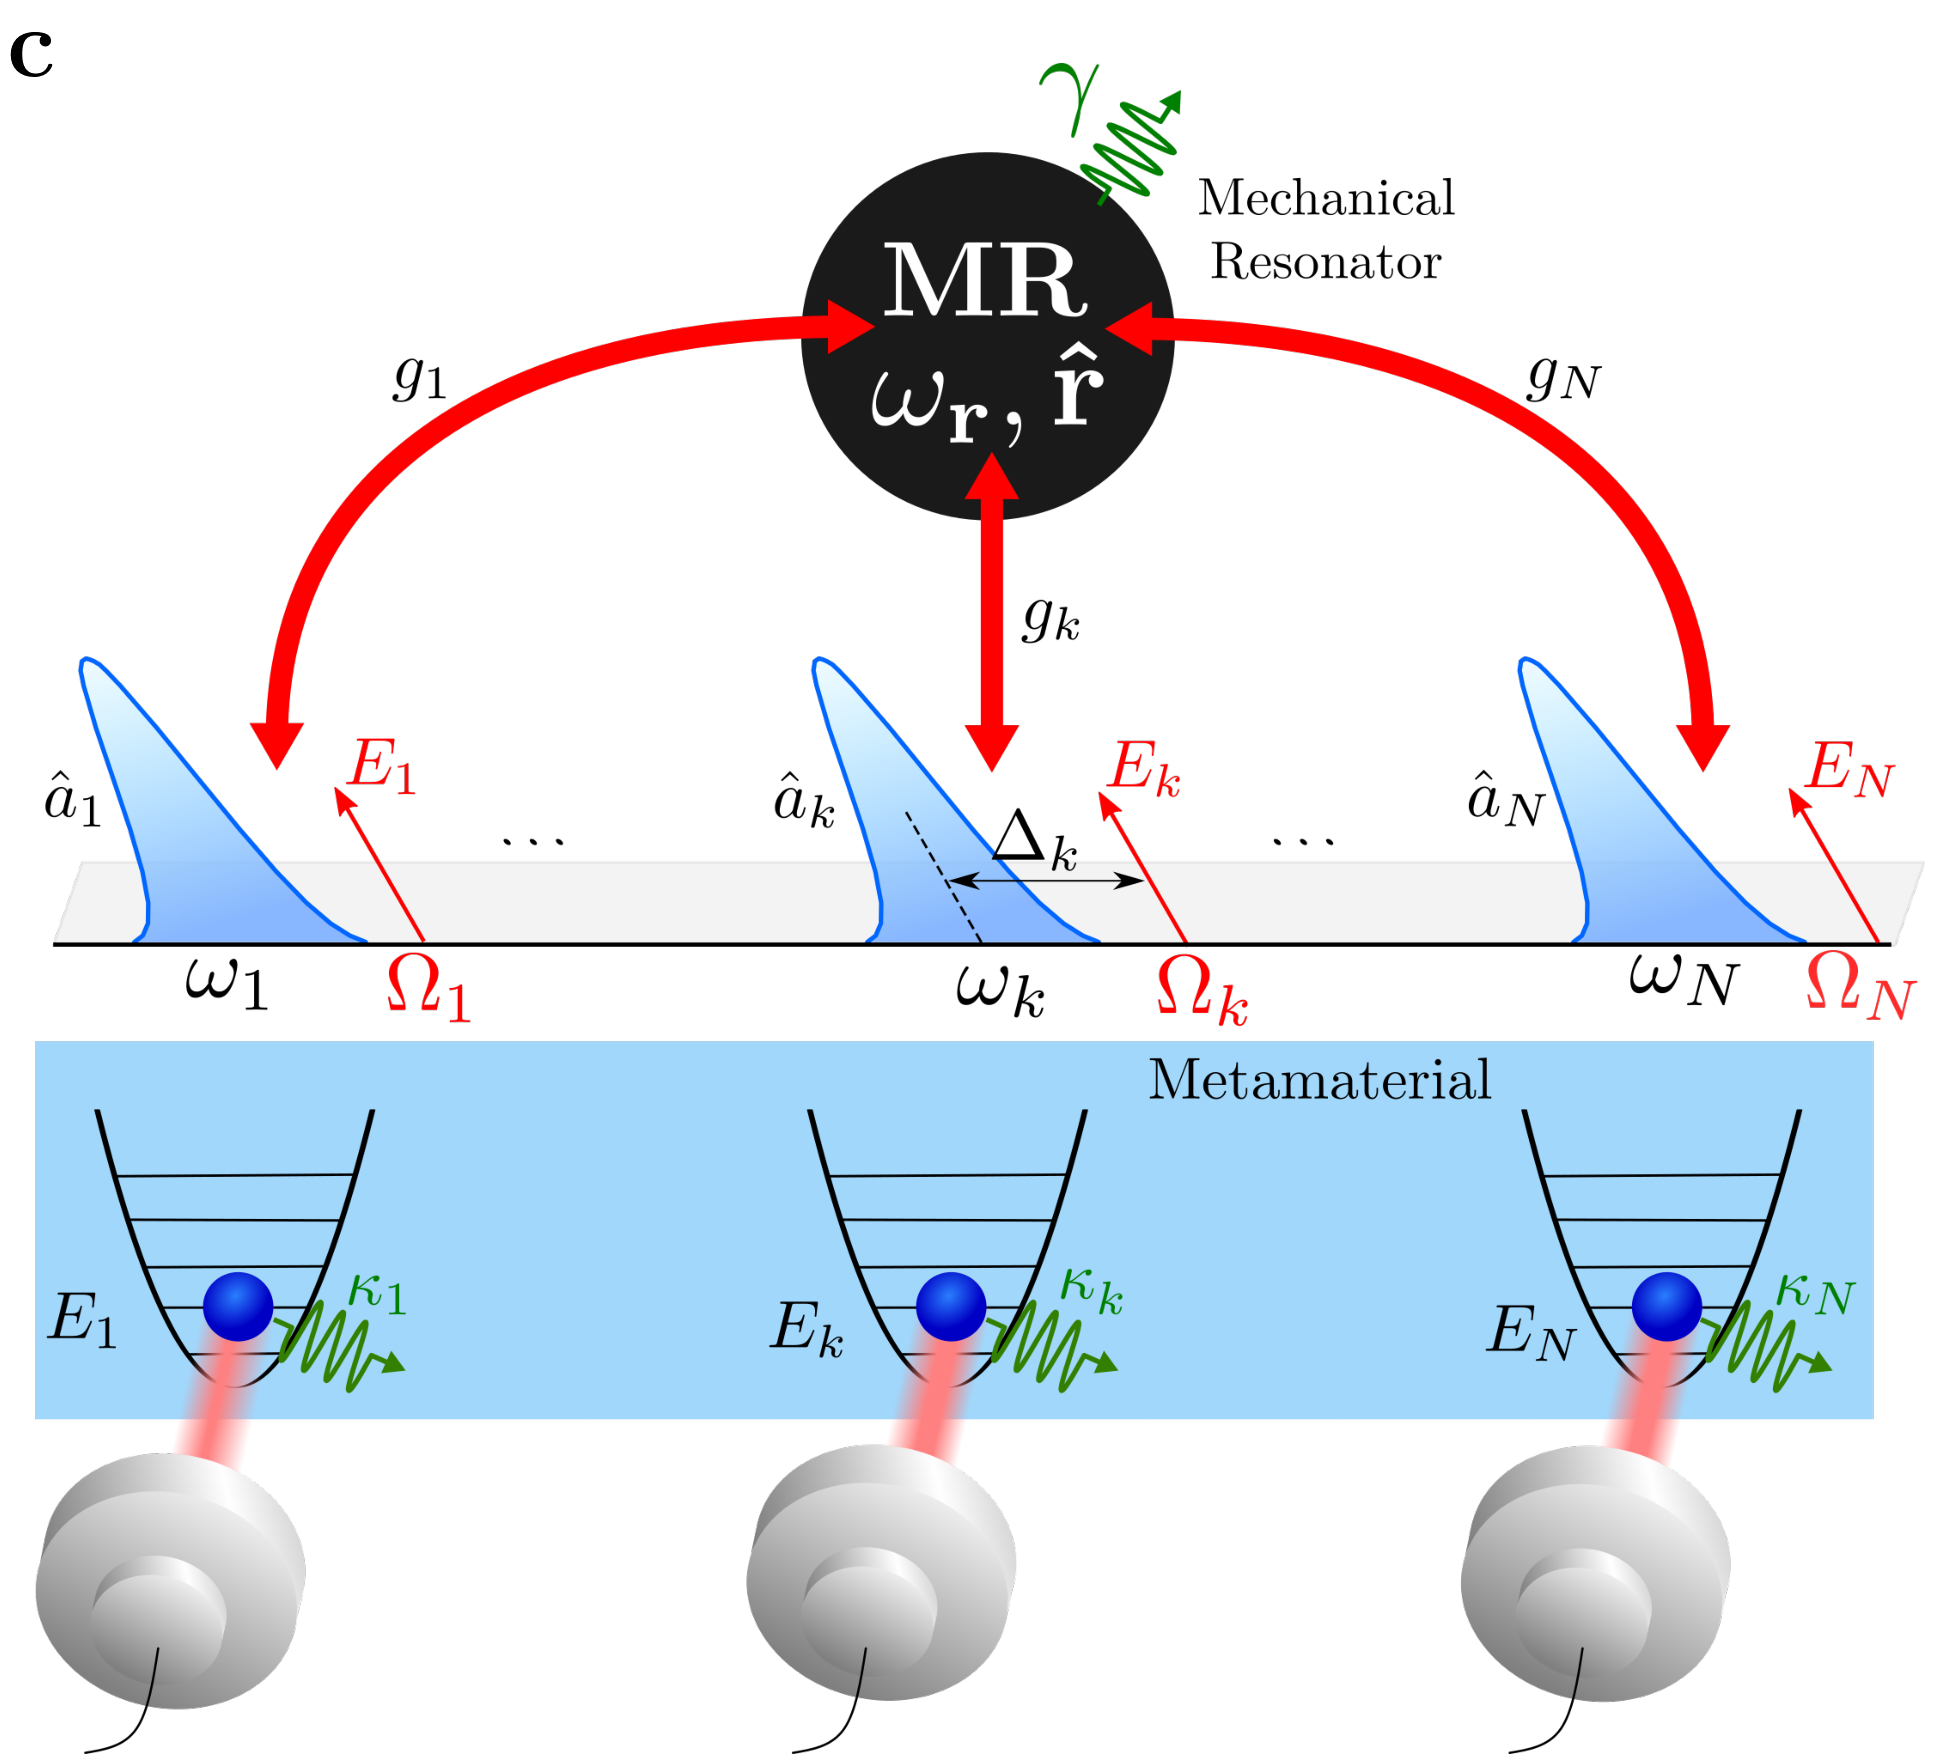

In [2]:
fig, axes = plt.subplots(1, 1, figsize=(20, 20))

img3 = mpimg.imread(r'Images\Metamaterial_MR_system_schematic.png')

axes.text(-30, 15, r"$\mathbf{c}$", color='black', fontsize=70)

plt.axis('off')
plt.imshow(img3)
plt.tight_layout()
if(saveResults == True):
    plt.savefig(r'Results/fig03_Metamaterial_MR_system_schematic_pdf.pdf')
    plt.savefig(r'Results/fig03_Metamaterial_MR_system_schematic_png.png')
plt.show()

## Metamaterial Circuit Resonator

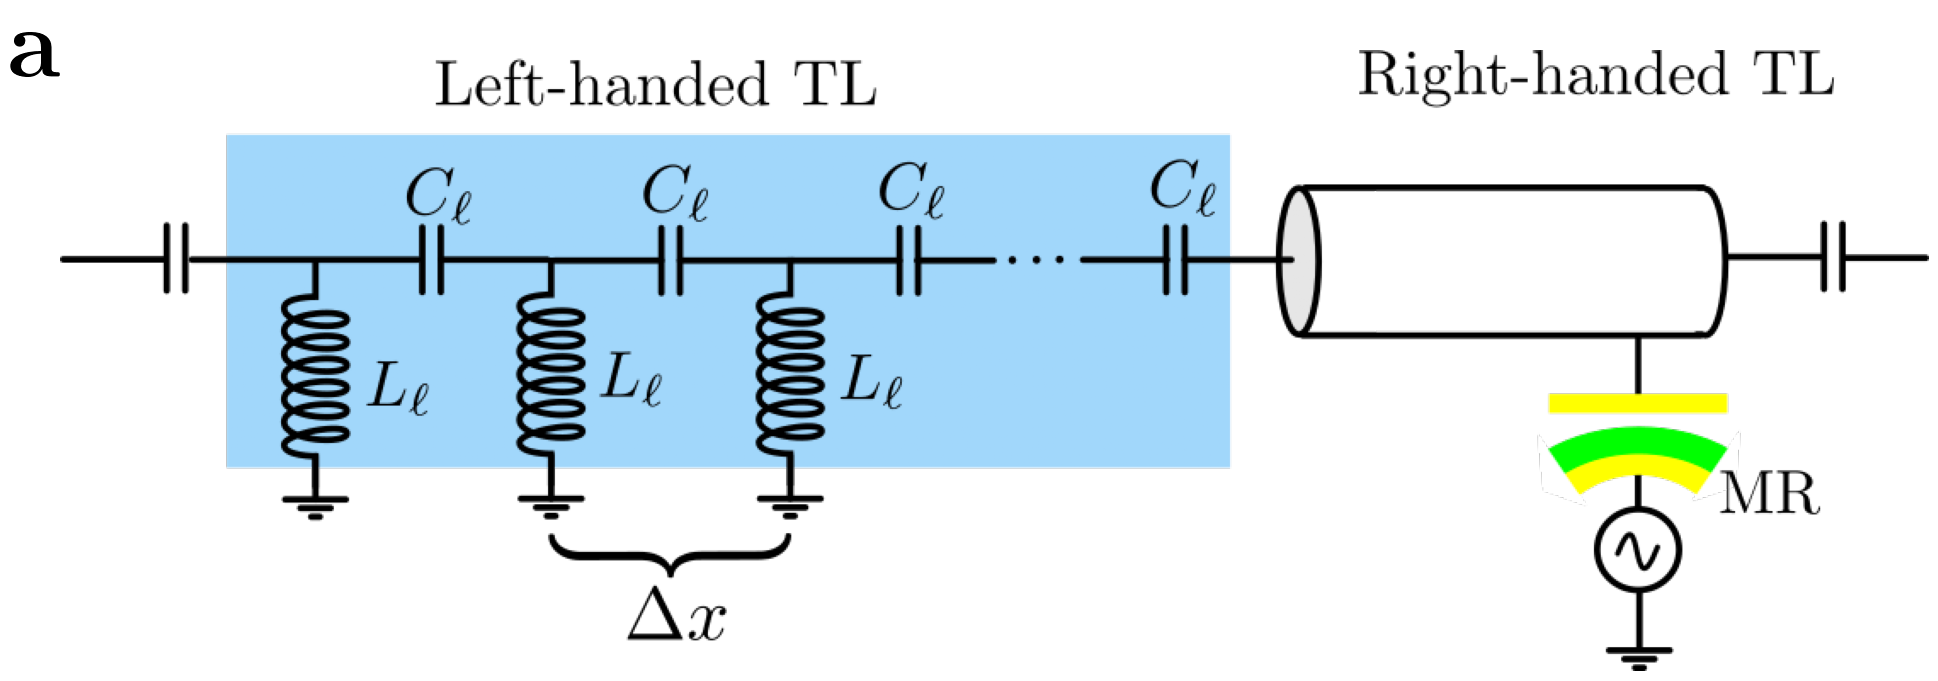

In [3]:
fig, axes = plt.subplots(1, 1, figsize=(20, 20))

img1 = mpimg.imread(r'Images\CTL_MechanicResonator_circuit_model.png')

axes.text(-30, 15, r"$\mathbf{a}$", color='black', fontsize=70)

plt.axis('off')
plt.imshow(img1)
plt.tight_layout()
if(saveResults == True):
    plt.savefig(r'Results/fig01_CTL_MechanicResonator_circuit_model_pdf.pdf')
    plt.savefig(r'Results/fig01_CTL_MechanicResonator_circuit_model_png.png')
plt.show()

In [4]:
characteristic_Impedance = 50  # Ohm
infrared_cutoff = 2 * pi * 5 * 1e9  # 5 GHz

capacitance_per_cell = (1 / (2 * infrared_cutoff * characteristic_Impedance))
inductance_per_cell = (characteristic_Impedance / (2 * infrared_cutoff))

print('Capacitance (C) = %.3f fF/cell' % (capacitance_per_cell*1e15))
print('Inductance (L) = %.3f pH/cell' % (inductance_per_cell*1e12))

Capacitance (C) = 318.310 fF/cell
Inductance (L) = 795.775 pH/cell


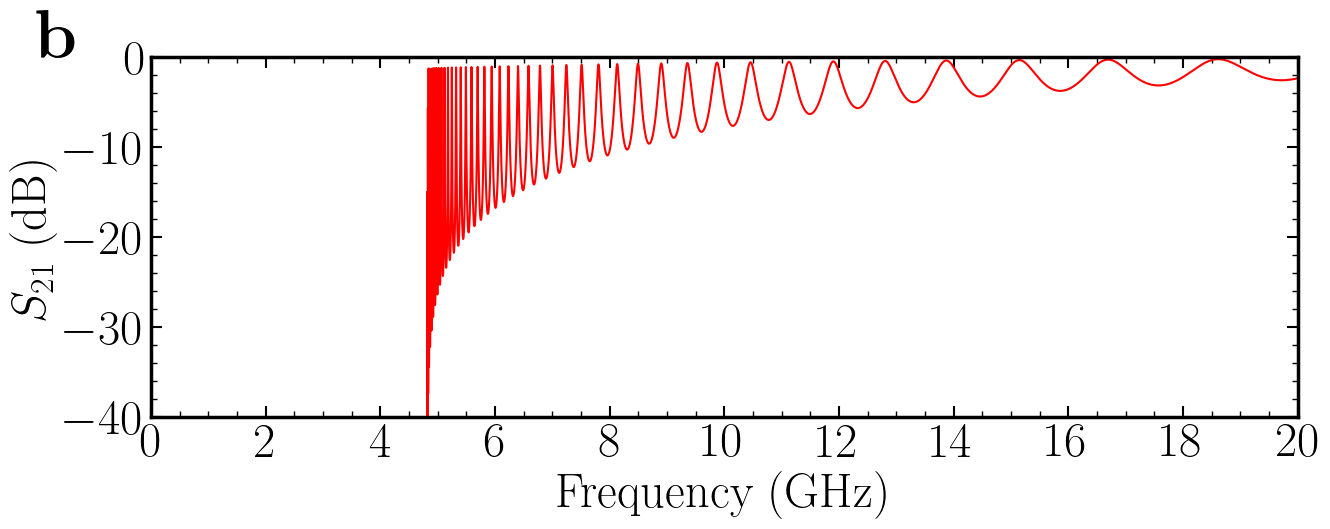

In [5]:
data_s21_artigo = loadtxt(r'Data/S21parameter_cutoff5GHz.txt')

x_list_s21artigo = data_s21_artigo[:,0]
y_list_s21artigo = data_s21_artigo[:,1]

fig, axes1 = plt.subplots(1, 1, figsize=(14, 6)) #14,7

axes1.plot(x_list_s21artigo, y_list_s21artigo, color='red', linestyle='-', label=r'Delta', lw=1.5)

axes1.set_xlabel(r'Frequency (GHz)', rotation=0, fontsize=35)
axes1.set_ylabel(
    r'$S_{21}$ (dB)', rotation=90, fontsize=35)

axes1.tick_params(axis='both', which='major', length = 8, direction='in', labelsize=35)
axes1.tick_params(axis='both', which='minor', length = 4, direction='in', labelsize=35)
#axes1.yaxis.tick_right()
axes1.xaxis.set_ticks_position('both')
axes1.yaxis.set_ticks_position('both')
#axes1.legend(loc=2, fontsize=23, frameon=False)

#axes1.set_xlim(0, 5778.04)
axes1.set_ylim(-40, 0)
axes1.set_xlim(0, 20)

start, end = axes1.get_ylim()
axes1.xaxis.set_ticks(arange(0, 20+1, 2))
axes1.yaxis.set_ticks(arange(start, end+1, 10))

axes1.xaxis.set_minor_locator(AutoMinorLocator())
axes1.yaxis.set_minor_locator(AutoMinorLocator())

axes1.set_ylim(-40, 0)
axes1.set_xlim(0, 20)

axes1.text(-2, 0, r"$\mathbf{b}$", color='black', fontsize=50)

plt.margins(x=0.01, y=0.01)
plt.tight_layout()

if(saveResults == True):
    plt.savefig(r'Results/fig02_S21_simulacaoCST_artigo.png')
    plt.savefig(r'Results/fig02_S21_simulacaoCST_artigo.pdf')
plt.show()

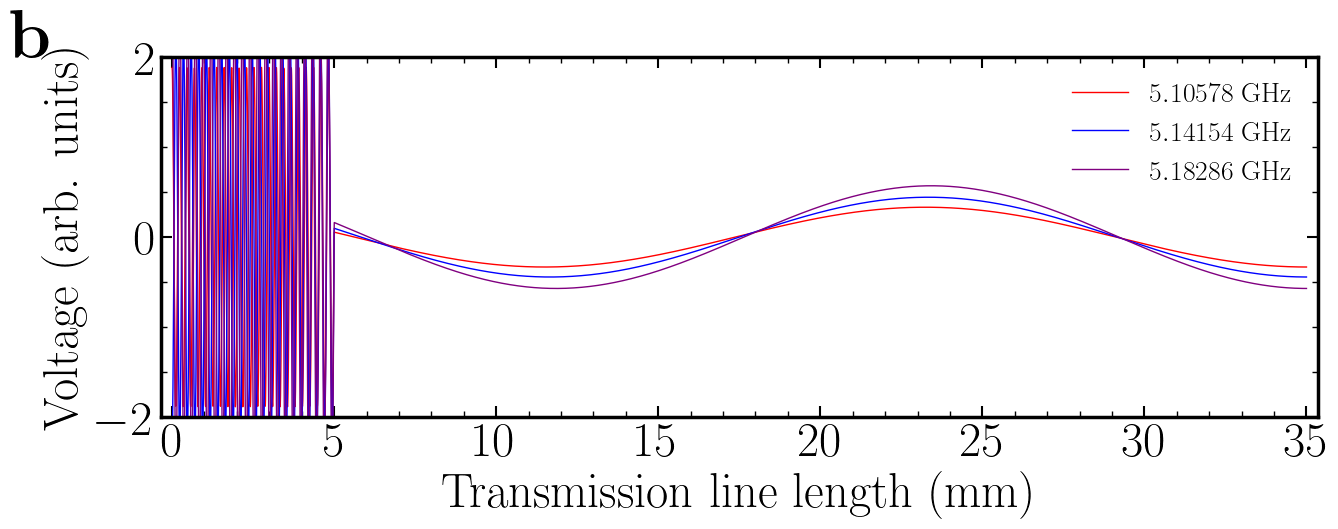

In [6]:
###############################
# Parameters from Mathematica calcultations
# Right-handed capacitance per unit of length = 0.1667 fF/um
# Right-handed inductance per unit of length = 0.4167 pH/um
# Left-handed capacitance = 318.310 fF
# Left-handed inductance  = 795.775 pH
# Number of unit cells = 50
# Unit cell length = Delta x = 100 um
# Right-handed TL length = 30 mm 
###############################

data_voltageMode1_fromMathematica = loadtxt(r'Data\data1_freq5105779.txt')
data_voltageMode2_fromMathematica = loadtxt(r'Data\data2_freq5141539.txt')
data_voltageMode3_fromMathematica = loadtxt(r'Data\data3_freq5182859.txt')

x1_list_length = data_voltageMode1_fromMathematica[:,0]*1000 + 5
y1_list_voltage = data_voltageMode1_fromMathematica[:,1]

x2_list_length = data_voltageMode2_fromMathematica[:,0]*1000  + 5
y2_list_voltage = data_voltageMode2_fromMathematica[:,1]

x3_list_length = data_voltageMode3_fromMathematica[:,0]*1000 + 5
y3_list_voltage = data_voltageMode3_fromMathematica[:,1]

fig, axes = plt.subplots(1, 1, figsize=(14, 6)) #14,7

axes.plot(x1_list_length, y1_list_voltage, color='red', linestyle='-', label=r'$5.10578$ GHz', lw=1.)
axes.plot(x2_list_length, y2_list_voltage, color='blue', linestyle='-', label=r'$5.14154$ GHz', lw=1.)
axes.plot(x3_list_length, y3_list_voltage, color='purple', linestyle='-', label=r'$5.18286$ GHz', lw=1.)

axes.set_xlabel(r'Transmission line length (mm)', rotation=0, fontsize=35)
axes.set_ylabel(r'Voltage (arb. units)', rotation=90, fontsize=35)

axes.tick_params(axis='both', which='major', length = 8, direction='in', labelsize=35)
axes.tick_params(axis='both', which='minor', length = 4, direction='in', labelsize=35)
#axes.yaxis.tick_right()
axes.xaxis.set_ticks_position('both')
axes.yaxis.set_ticks_position('both')
#axes.legend(loc=2, fontsize=23, frameon=False)

#axes.set_xlim(0, 5778.04)
#axes.set_ylim(-40, 0)
axes.set_ylim(-2, 2)

#start, end = axes.get_ylim()
axes.xaxis.set_ticks(arange(0, 35+1, 5))
#axes.yaxis.set_ticks(arange(start, end+1, 10))

axes.xaxis.set_minor_locator(AutoMinorLocator())
axes.yaxis.set_minor_locator(AutoMinorLocator())

#axes.set_ylim(-40, 0)
#axes.set_xlim(0, 20)

axes.text(-5, 2, r"$\mathbf{b}$", color='black', fontsize=50)
#axes.text(-5, -1.5, r"Right-handed", color='black', fontsize=30)
#axes.text(10, -1.5, r"Left-handed", color='black', fontsize=30)


axes.legend(loc=1,fontsize=20,frameon=False)

plt.margins(x=0.01, y=0.01)
plt.tight_layout()



if(saveResults == True):
    plt.savefig(r'Results/fig02_S21_simulacaoCST_artigo.png')
    plt.savefig(r'Results/fig02_S21_simulacaoCST_artigo.pdf')
plt.show()

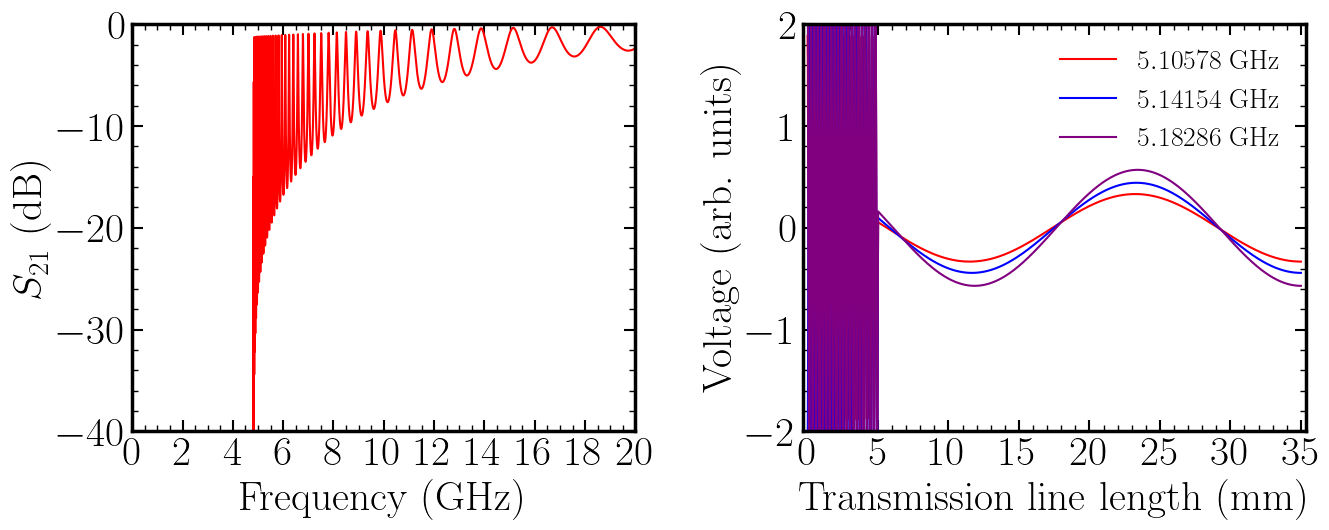

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 

axes[0].plot(x_list_s21artigo, y_list_s21artigo, color='red', linestyle='-', label=r'Delta', lw=1.5)

axes[0].set_xlabel(r'Frequency (GHz)', rotation=0, fontsize=30)
axes[0].set_ylabel(
    r'$S_{21}$ (dB)', rotation=90, fontsize=30)

axes[0].tick_params(axis='both', which='major', length = 8, direction='in', labelsize=30)
axes[0].tick_params(axis='both', which='minor', length = 4, direction='in', labelsize=30)
#axes.yaxis.tick_right()
axes[0].xaxis.set_ticks_position('both')
axes[0].yaxis.set_ticks_position('both')
#axes.legend(loc=2, fontsize=23, frameon=False)

#axes.set_xlim(0, 5778.04)
axes[0].set_ylim(-40, 0)
axes[0].set_xlim(0, 20)

start, end = axes[0].get_ylim()
axes[0].xaxis.set_ticks(arange(0, 20+1, 2))
axes[0].yaxis.set_ticks(arange(start, end+1, 10))

axes[0].xaxis.set_minor_locator(AutoMinorLocator())
axes[0].yaxis.set_minor_locator(AutoMinorLocator())

axes[0].set_ylim(-40, 0)
axes[0].set_xlim(0, 20)

#axes.text(-2, 0, r"$\mathbf{b}$", color='black', fontsize=50)

axes[1].plot(x1_list_length, y1_list_voltage, color='red', linestyle='-', label=r'$5.10578$ GHz', lw=1.5)
axes[1].plot(x2_list_length, y2_list_voltage, color='blue', linestyle='-', label=r'$5.14154$ GHz', lw=1.5)
axes[1].plot(x3_list_length, y3_list_voltage, color='purple', linestyle='-', label=r'$5.18286$ GHz', lw=1.5)

axes[1].set_xlabel(r'Transmission line length (mm)', rotation=0, fontsize=30)
axes[1].set_ylabel(r'Voltage (arb. units)', rotation=90, fontsize=30)

axes[1].tick_params(axis='both', which='major', length = 8, direction='in', labelsize=30)
axes[1].tick_params(axis='both', which='minor', length = 4, direction='in', labelsize=30)
#axes[1].yaxis.tick_right()
axes[1].xaxis.set_ticks_position('both')
axes[1].yaxis.set_ticks_position('both')
#axes[1].legend(loc=2, fontsize=23, frameon=False)

#axes[1].set_xlim(0, 5778.04)
#axes[1].set_ylim(-40, 0)
axes[1].set_ylim(-2, 2)

#start, end = axes[1].get_ylim()
axes[1].xaxis.set_ticks(arange(0, 35+1, 5))
#axes[1].yaxis.set_ticks(arange(start, end+1, 10))

axes[1].xaxis.set_minor_locator(AutoMinorLocator())
axes[1].yaxis.set_minor_locator(AutoMinorLocator())

#axes[1].set_ylim(-40, 0)
#axes[1].set_xlim(0, 20)

#axes[1].text(-10, 2, r"$\mathbf{b}$", color='black', fontsize=50)
#axes[1].text(-5, -1.5, r"Right-handed", color='black', fontsize=30)
#axes[1].text(10, -1.5, r"Left-handed", color='black', fontsize=30)


axes[1].legend(loc=1,fontsize=20,frameon=False)

plt.margins(x=0.01, y=0.01)
plt.tight_layout()

if(saveResults == True):
    plt.savefig(r'Results/fig02_S21_simulacaoCST_artigo.png')
    plt.savefig(r'Results/fig02_S21_simulacaoCST_artigo.pdf')
plt.show()

## Temperature and Dimension Test

In [9]:
w_test1 = 2 * pi * 10 * 1e6   # Test frequency = 10 MHz
w_test2 = 2 * pi * 20 * 1e6   # Test frequency = 20 MHz
w_test3 = 2 * pi * 50 * 1e6   # Test frequency = 50 MHz
w_test4 = 2 * pi * 100 * 1e6  # Test frequency = 100 MHz

w_test5 = 2 * pi * 1 * 1e9  # Test frequency = 1 GHz
w_test6 = 2 * pi * 5 * 1e9  # Test frequency = 5 GHz

test_frequencies = [w_test1, w_test2, w_test3, w_test4, w_test5, w_test6]

test_temperatures = linspace(0.001, 0.1, 200) 
test_dimensions = arange(3,16,1)                        

list_exc0_temp_vs_dim_freq = []
list_exc1_temp_vs_dim_freq = []
list_exc2_temp_vs_dim_freq = []
list_exc3_temp_vs_dim_freq = []
list_exc4_temp_vs_dim_freq = []

for k in test_frequencies:
    list_exc0_temp_vs_dim = []
    list_exc1_temp_vs_dim = []
    list_exc2_temp_vs_dim = []
    list_exc3_temp_vs_dim = []
    list_exc4_temp_vs_dim = []
    for i in test_temperatures:
        list_exc0_dim = []
        list_exc1_dim = []
        list_exc2_dim = []
        list_exc3_dim = []
        list_exc4_dim = [] 
        for l in test_dimensions:
            w_th = (sc.k*i)/(sc.hbar)
            n_th = n_thermal(k, w_th)
            list_exc0_dim.append(real(thermal_dm(l, n_th)[0,0]))
            list_exc1_dim.append(real(thermal_dm(l, n_th)[1,1]))
            list_exc2_dim.append(real(thermal_dm(l, n_th)[2,2]))
            if l > 3:
                list_exc3_dim.append(real(thermal_dm(l, n_th)[3,3]))
                if l > 4:
                    list_exc4_dim.append(real(thermal_dm(l, n_th)[4,4]))
                else:
                    list_exc4_dim.append(0)
            else:
                list_exc3_dim.append(0)
                list_exc4_dim.append(0)

        list_exc0_temp_vs_dim.append(list_exc0_dim)
        list_exc1_temp_vs_dim.append(list_exc1_dim)
        list_exc2_temp_vs_dim.append(list_exc2_dim)
        list_exc3_temp_vs_dim.append(list_exc3_dim)
        list_exc4_temp_vs_dim.append(list_exc4_dim)
    list_exc0_temp_vs_dim_freq.append(list_exc0_temp_vs_dim)
    list_exc1_temp_vs_dim_freq.append(list_exc1_temp_vs_dim)
    list_exc2_temp_vs_dim_freq.append(list_exc2_temp_vs_dim)
    list_exc3_temp_vs_dim_freq.append(list_exc3_temp_vs_dim)
    list_exc4_temp_vs_dim_freq.append(list_exc4_temp_vs_dim)

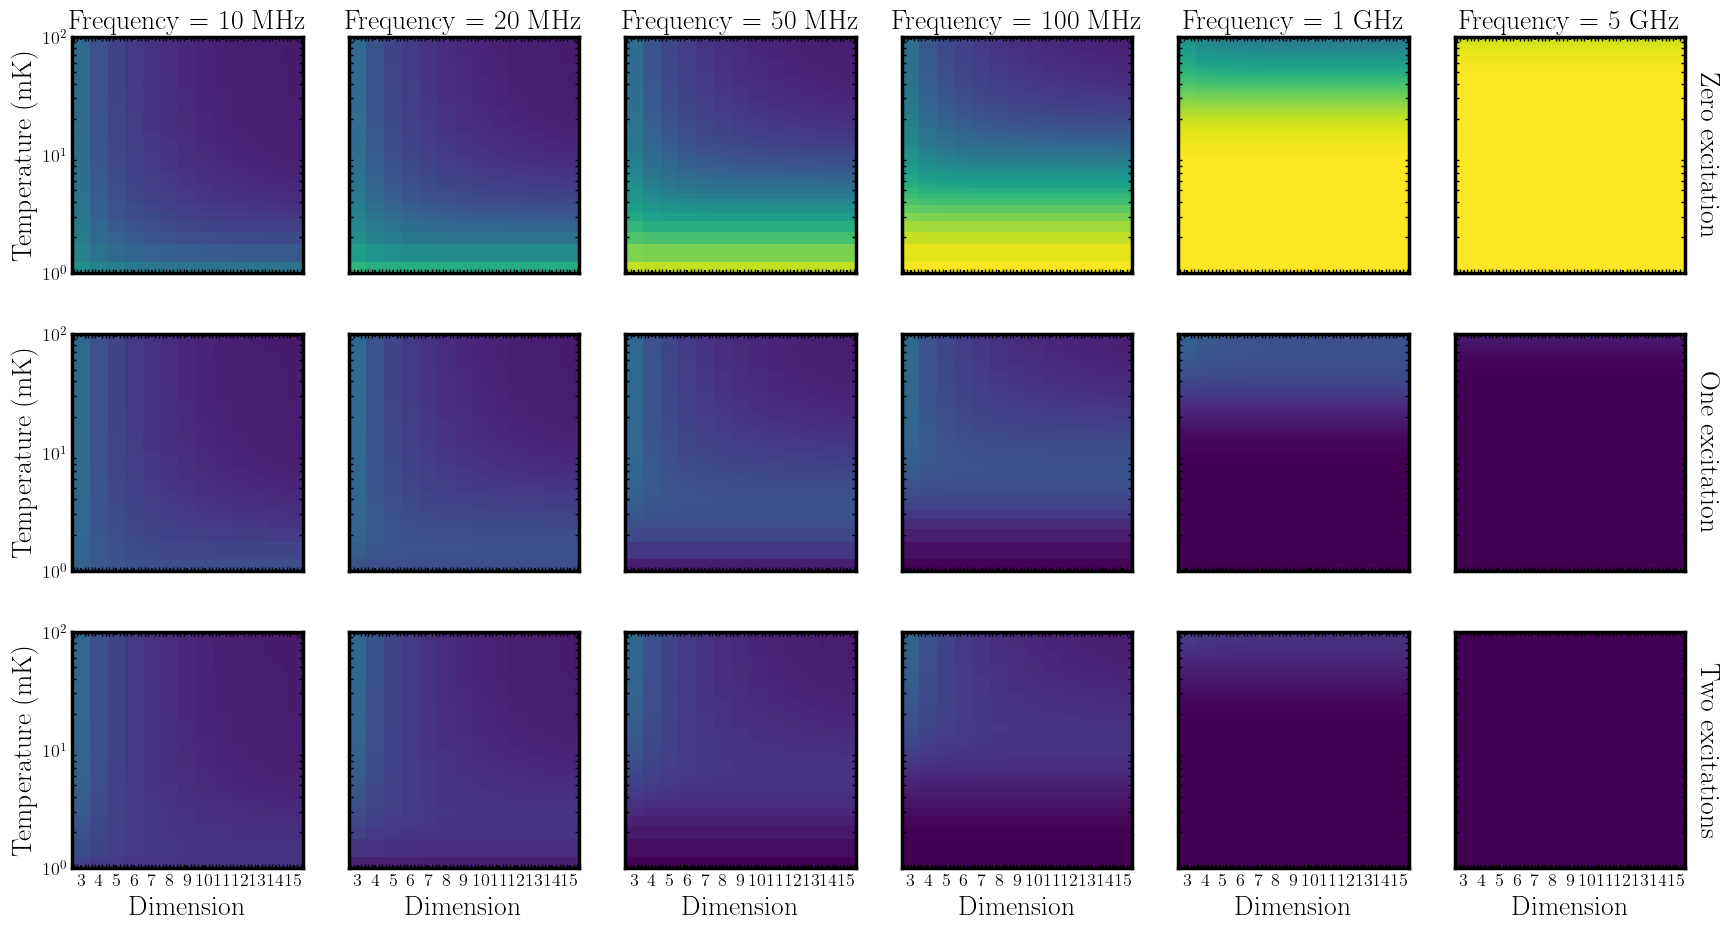

In [10]:
fig, axes = plt.subplots(3, 6, figsize=(18, 10),sharey=True,sharex=True)

Lsize = 20

nrm = mpl.colors.Normalize(0, 1)

########################
# Use 'norm = nrm' below to normalize the probability colormap from 0 to 1. Otherwise, 
# use 'norm = nrm1' (or 'norm = nrm2' or 'norm = nrm3', depending on the excitation) to
# normalize the colomap according to the local maximum.
########################

for k in range(0,len(test_frequencies)):
    nrm1 = mpl.colors.Normalize(0, max(list_exc0_temp_vs_dim_freq[k][0]))
    axes[0,k].pcolormesh(test_dimensions, test_temperatures*1000, list_exc0_temp_vs_dim_freq[k], cmap=cm.viridis, norm=nrm, shading='auto')
    axes[0,0].set_ylabel(r'Temperature (mK)', rotation=90, fontsize=Lsize)
    axes[0,5].yaxis.set_label_position("right")
    axes[0,5].set_ylabel(r'Zero excitation', labelpad = 25, rotation=270, fontsize=Lsize)
    axes[0,k].tick_params(axis='both', which='major', direction='in', labelsize=13)
    axes[0,k].tick_params(axis='both', which='minor', direction='in', labelsize=13)
    axes[0,k].xaxis.set_ticks(arange(3, 16, 1))
    axes[0,k].yaxis.set_ticks_position('both')
    axes[0,k].yaxis.set_minor_locator(AutoMinorLocator(2))
    axes[0,k].xaxis.set_tick_params(length=2)
    axes[0,k].yaxis.set_tick_params(length=1)
    axes[0,k].set_ylim(1,100)

    nrm2 = mpl.colors.Normalize(0, max(list_exc1_temp_vs_dim_freq[k][-1]))
    axes[1,k].pcolormesh(test_dimensions, test_temperatures*1000, list_exc1_temp_vs_dim_freq[k], cmap=cm.viridis, norm=nrm, shading='auto')
    axes[1,0].set_ylabel(r'Temperature (mK)', rotation=90, fontsize=Lsize)
    axes[1,5].yaxis.set_label_position("right")
    axes[1,5].set_ylabel(r'One excitation', labelpad = 25, rotation=270, fontsize=Lsize)
    axes[1,k].tick_params(axis='both', which='major', direction='in', labelsize=13)
    axes[1,k].tick_params(axis='both', which='minor', direction='in', labelsize=13)
    axes[1,k].xaxis.set_ticks(arange(3, 16, 1))
    axes[1,k].yaxis.set_ticks_position('both')
    axes[1,k].yaxis.set_minor_locator(AutoMinorLocator(2))
    axes[1,k].xaxis.set_tick_params(length=2)
    axes[1,k].yaxis.set_tick_params(length=1)
    axes[1,k].set_yscale('log')
    axes[1,k].set_ylim(1,100)

    nrm3 = mpl.colors.Normalize(0, max(list_exc2_temp_vs_dim_freq[k][-1]))
    axes[2,k].pcolormesh(test_dimensions, test_temperatures*1000, list_exc2_temp_vs_dim_freq[k], cmap=cm.viridis, norm=nrm, shading='auto')
    axes[2,k].set_xlabel(r'Dimension', rotation=0, fontsize=Lsize)
    axes[2,0].set_ylabel(r'Temperature (mK)', rotation=90, fontsize=Lsize)
    axes[2,5].yaxis.set_label_position("right")
    axes[2,5].set_ylabel(r'Two excitations', labelpad = 25, rotation=270, fontsize=Lsize)
    axes[2,k].tick_params(axis='both', which='major', direction='in', labelsize=13)
    axes[2,k].tick_params(axis='both', which='minor', direction='in', labelsize=13)
    axes[2,k].xaxis.set_ticks(arange(3, 16, 1))
    axes[2,k].yaxis.set_ticks_position('both')
    axes[2,k].yaxis.set_minor_locator(AutoMinorLocator(2))
    axes[2,k].xaxis.set_tick_params(length=2)
    axes[2,k].yaxis.set_tick_params(length=1)
    axes[2,k].set_yscale('log')
    axes[2,k].set_ylim(1,100)
    
axes[0,0].set_title(r'Frequency = 10 MHz', fontsize=Lsize)
axes[0,1].set_title(r'Frequency = 20 MHz', fontsize=Lsize)
axes[0,2].set_title(r'Frequency = 50 MHz', fontsize=Lsize)
axes[0,3].set_title(r'Frequency = 100 MHz', fontsize=Lsize)
axes[0,4].set_title(r'Frequency = 1 GHz', fontsize=Lsize)
axes[0,5].set_title(r'Frequency = 5 GHz', fontsize=Lsize)

plt.tight_layout()
plt.show()


## Blockade Regime Range of parameters

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import os
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches

# ======================================================================================
# Parameters
# ======================================================================================

omega_r_list = [10, 50, 100, 1000]   # MHz

#kappa_1_list = np.logspace(-3, 1, 500)   # MHz
#g_1_list     = np.logspace(-2, 4, 500)   # MHz

kappa_1_list = np.logspace(-4, 5.5, 600)   # MHz
g_1_list     = np.logspace(-7, 4, 600)   # MHz

KAPPA_1, G_1 = np.meshgrid(kappa_1_list, g_1_list)

chosen_points = [
    #{
    #    "kappa_1": 0.08,
    #    "g_1": 5.0,
    #    "label": " ",
    #    "color": "black",
    #    "marker": "o"
    #},

    # Same linewidth scale
    {
        "kappa_1": 0.20,
        "g_1": 2e-4,
        "label": "Teufel 2011",
        "color": "tab:blue",
        "marker": "s"
    },
    {
        "kappa_1": 0.0455,
        "g_1": 3.6e-7,
        "label": "Yuan 2015",
        "color": "tab:cyan",
        "marker": "v"
    },
    {
        "kappa_1": 0.38,
        "g_1": 0.0036,
        "label": "Bothner 2022",
        "color": "tab:purple",
        "marker": "D"
    },

     #Same coupling scale
    {
        "kappa_1": 8.0,
        "g_1": 0.160,
        "label": "Bera 2024",
        "color": "tab:red",
        "marker": "o",
        "rotation": 15
    },
    {
        "kappa_1": 255.0,
        "g_1": 1.08,
        "label": "Qiu 2020",
        "color": "tab:orange",
        "marker": "^"
    },
    {
        "kappa_1": 2400.0,
        "g_1": 1.0,
        "label": "Chen 2026",
        "color": "tab:green",
        "marker": "P"
    }
]
chosen_regions = [
    {
        "kappa_min": 0.05,   # 20 kHz = 0.05 MHz
        "kappa_max": 0.20,   # 500 kHz = 0.20 MHz
        "g_min": 0.50,       # 10 kHz = 0.10 MHz
        "g_max": 15.0,       # 15 MHz
        "label": "Simulation parameters",
        "edgecolor": "black",
        "facecolor": "none",
        "alpha": 0.9,
        "linestyle": ":",
        "linewidth": 1.8
    }
]

# Constant blockade-ratio lines
#ratio_values = [1e-3, 1e-2, 1e-1, 1, 10, 100]
ratio_values = [1e-12,1e-9, 1e-6, 1e-3, 1e-1, 1, 10, 100]

save_folder = "Results_Blockade_Regime"
os.makedirs(save_folder, exist_ok=True)

# ======================================================================================
# Helper functions
# ======================================================================================

def g_from_ratio(kappa_vals, omega_r, ratio):
    """
    ratio = (2 g_1^2 / omega_r) / kappa_1
    => g_1 = sqrt(ratio * omega_r * kappa_1 / 2)
    """
    return np.sqrt(ratio * omega_r * kappa_vals / 2.0)


def add_ratio_line_labels(ax, omega_r, ratio_values, x_positions,
                          color_regular="maroon", color_boundary="darkgreen"):
    """
    Put a label directly on each R_B line.
    x_positions should have same length as ratio_values or more.
    """

    ymin, ymax = ax.get_ylim()

    for i, R in enumerate(ratio_values):
        x0 = x_positions[min(i, len(x_positions)-1)]
        y0 = g_from_ratio(np.array([x0]), omega_r, R)[0]

        if ymin < y0 < ymax:
            if np.isclose(R, 1.0):
                color = color_boundary
                weight = "bold"
            else:
                color = color_regular
                weight = "normal"
            if np.isclose(R, 1.0):
                ax.text(
                    x0,
                    y0 * 3.3,
                    format_RB_label(R),
                    color=color,
                    fontsize=10,
                    fontweight=weight,
                    rotation=25,
                    ha="left",
                    va="center",
                    zorder=5
                )
            else:
                ax.text(
                    x0,
                    y0 * 4.5,
                    format_RB_label(R),
                    color=color,
                    fontsize=10,
                    fontweight=weight,
                    rotation=25,
                    ha="left",
                    va="center",
                    zorder=5
                )

def log_position(vmin, vmax, frac):
    """
    Position a value by fraction on a log axis.
    frac=0 gives vmin, frac=1 gives vmax.
    """
    return 10**(np.log10(vmin) + frac * (np.log10(vmax) - np.log10(vmin)))


def place_regime_labels(ax, omega_r, kappa_1_list, g_1_list):
    """
    Places labels in fixed useful positions:
    - Blockade Region: horizontal and slightly below g_1 = omega_r
    - Weak Nonlinearity: bottom right of the panel
    """

    x_min = kappa_1_list.min()
    x_max = kappa_1_list.max()

    y_min = g_1_list.min()
    y_max = g_1_list.max()

    # Put blockade label slightly below the ultra-strong boundary g_1 = omega_r
    x_blockade = log_position(x_min, x_max, 0.55)
    y_blockade = omega_r / 1.45

    # Keep the label inside the visible panel
    y_blockade = min(max(y_blockade, 1.8 * y_min), 0.8 * y_max)

    ax.text(
        x_blockade*0.001,
        y_blockade,
        "Blockade Region",
        fontsize=15,
        color="darkgreen",
        ha="center",
        va="top",
        rotation=0,
        zorder = 14
    )

    # Put weak-nonlinearity label always at bottom right
    ax.text(
        0.7,
        0.05,
        "Weak Nonlinearity",
        transform=ax.transAxes,
        fontsize=17,
        color="#9b174c",
        ha="center",
        va="bottom",
        rotation=0,
        zorder = 9
    )

def format_RB_label(R):
    """
    Format blockade ratio labels.

    Exceptions:
        R_B = 1  -> write R_B = 1
        R_B = 10 -> write R_B = 10

    Other values are written in scientific notation.
    """

    if np.isclose(R, 1.0):
        return r"$\mathbf{R_B=1}$"

    elif np.isclose(R, 10.0):
        return r"$R_B=10$"

    else:
        exponent = int(np.round(np.log10(R)))
        return rf"$R_B=10^{{{exponent}}}$"

def format_wr_title(omega_r):
    """
    Format omega_r title.
    If omega_r is below 1000 MHz, write it in MHz.
    If omega_r is 1000 MHz or above, write it in GHz.
    """
    if omega_r >= 1000:
        omega_ghz = omega_r / 1000

        if omega_ghz.is_integer():
            omega_ghz = int(omega_ghz)

        return rf"$\omega_r/2\pi = {omega_ghz}\,\mathrm{{GHz}}$"

    else:
        if float(omega_r).is_integer():
            omega_r = int(omega_r)

        return rf"$\omega_r/2\pi = {omega_r}\,\mathrm{{MHz}}$"

### 4-Panels Plot


Saved:
Thesis_Figures\chap4_blockade_region_parameters.pdf


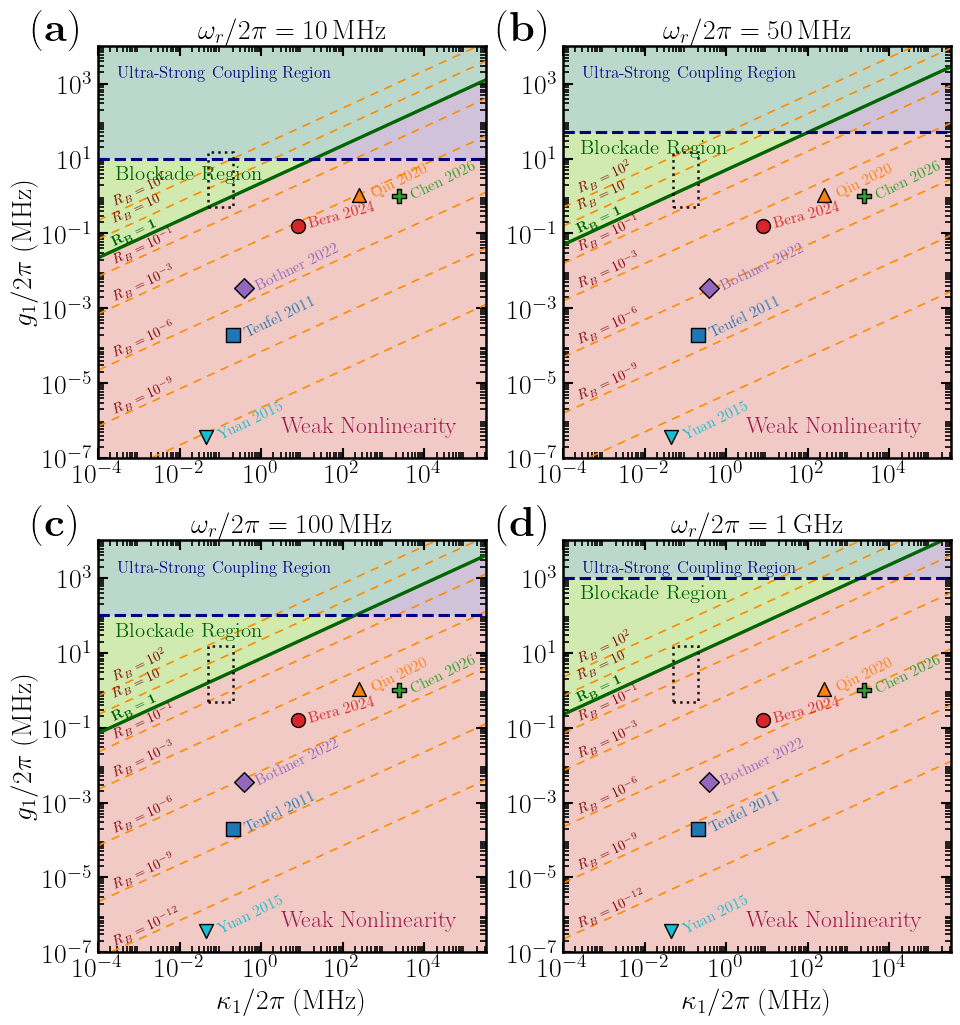

In [19]:
# ======================================================================================
# 4-panel version
# ======================================================================================
def plot_regime_diagram_4panels(save_fig=True):

    fig, axes = plt.subplots(2, 2, figsize=(11, 12))
    axes = axes.flatten()

    for i, (ax, omega_r) in enumerate(zip(axes, omega_r_list)):

        ratio_grid   = (2 * G_1**2 / omega_r) / KAPPA_1
        blockade     = ratio_grid > 1
        below_block  = ratio_grid < 1
        ultrastrong  = G_1 > omega_r

        ax.set_facecolor("#f4f1c4")

        ax.contourf(
            KAPPA_1, G_1, below_block.astype(float),
            levels=[0.5, 1.5],
            colors=["#efb0c9"],
            alpha=0.60
        )

        ax.contourf(
            KAPPA_1, G_1, blockade.astype(float),
            levels=[0.5, 1.5],
            colors=["#b8e6a3"],
            alpha=0.60
        )

        ax.contourf(
            KAPPA_1, G_1, ultrastrong.astype(float),
            levels=[0.5, 1.5],
            colors=["#93b7ff"],
            alpha=0.35
        )

        for R in ratio_values:
            g_line = g_from_ratio(kappa_1_list, omega_r, R)

            if np.any((g_line >= g_1_list.min()) & (g_line <= g_1_list.max())):
                if np.isclose(R, 1.0):
                    ax.plot(kappa_1_list, g_line, color="darkgreen", lw=2.4)
                else:
                    ax.plot(
                        kappa_1_list, g_line,
                        color="darkorange",
                        lw=1.2,
                        ls=(0, (5, 4))
                    )

        for region in chosen_regions:
            rect = mpatches.Rectangle(
                (region["kappa_min"], region["g_min"]),
                region["kappa_max"] - region["kappa_min"],
                region["g_max"] - region["g_min"],
                facecolor=region.get("facecolor"),
                edgecolor=region.get("edgecolor"),
                alpha=region.get("alpha"),
                linestyle=region.get("linestyle"),
                linewidth=region.get("linewidth"),
                zorder=8
            )

            ax.add_patch(rect)


        ax.axhline(omega_r, color="navy", lw=2.2, ls="--")

        place_regime_labels(
        ax=ax,
        omega_r=omega_r,
        kappa_1_list=kappa_1_list,
        g_1_list=g_1_list
        )

        ax.text(
            0.05, 0.95,
            "Ultra-Strong Coupling Region",
            transform=ax.transAxes,
            fontsize=12,
            color="navy",
            rotation=0,
            va="top"
        )

        #x_positions_for_labels = [1.5e-3, 4e-3, 1.3e-2, 4e-2, 1.5e-1, 5e-1]
        x_positions_for_labels = [2e-4, 2e-4, 2e-4,2e-4, 2e-4, 2e-4]
        #x_positions_for_labels = [9e-1, 10e-1, 11e-1, 14e-1, 13e-1, 13e-1]
        add_ratio_line_labels(
            ax=ax,
            omega_r=omega_r,
            ratio_values=ratio_values,
            x_positions=x_positions_for_labels
        )

        for point in chosen_points:
            ax.scatter(
                point["kappa_1"],
                point["g_1"],
                s=100,
                color=point.get("color", "black"),
                marker=point.get("marker", "o"),
                edgecolor="black",
                linewidth=1.0,
                zorder=10
            )

            ax.annotate(
                point["label"],
                xy=(point["kappa_1"], point["g_1"]),
                xytext=(7, -2),
                textcoords="offset points",
                fontsize=11,
                rotation=point.get("rotation", 26),
                color=point.get("color", "black"),
                zorder=11
            )

        ax.set_xscale("log")
        ax.set_yscale("log")

        ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=5))
        ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=10))

        ax.xaxis.set_minor_locator(
            ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100)
        )
        ax.yaxis.set_minor_locator(
            ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100)
        )

        ax.xaxis.set_major_formatter(ticker.LogFormatterMathtext(base=10.0))
        ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext(base=10.0))

        ax.set_xlim(kappa_1_list.min(), kappa_1_list.max())
        ax.set_ylim(g_1_list.min(), g_1_list.max())

        ax.set_title(format_wr_title(omega_r), fontsize=20)
        # xlabel only for bottom row
        if i in [2, 3]:
            ax.set_xlabel(r"$\kappa_1/2\pi$ (MHz)", fontsize=20)
        else:
            ax.set_xlabel("")

        # ylabel only for left column
        if i in [0, 2]:
            ax.set_ylabel(r"$g_1/2\pi$ (MHz)", fontsize=20)
        else:
            ax.set_ylabel("")

        ax.tick_params(
            axis="both",
            which="major",
            direction="in",
            top=True,
            right=True,
            labelsize=20,
            length=7,
            width=1.5
        )

        ax.tick_params(
            axis="both",
            which="minor",
            direction="in",
            top=True,
            right=True,
            labelsize=0,
            length=4,
            width=1.2
        )

        for spine in ax.spines.values():
            spine.set_linewidth(1.8)

    ratio_handles = [
        mlines.Line2D([], [], color="maroon", lw=1.8, ls=(0, (8, 6)),
                      label=rf"$R_B={R:g}$")
        for R in ratio_values if not np.isclose(R, 1.0)
    ]
    boundary_handle = mlines.Line2D([], [], color="darkgreen", lw=2.4, label=r"$R_B=1$")
    ultra_handle = mlines.Line2D([], [], color="navy", lw=2.2, ls="--", label=r"$g_1=\omega_r$")
    point_handle = mlines.Line2D([], [], color="black", marker="o", linestyle="None",
                                 markersize=7, label="Our parameters")

    #=====================================================
    # Overlays
    #=====================================================
    labels = [r'$\mathbf{(a)}$', r'$\mathbf{(b)}$', r'$\mathbf{(c)}$', r'$\mathbf{(d)}$']

    for ax, label in zip(axes, labels):
        ax.text(
            -0.17, 1.09, label,
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontsize=30,
            color='black'
        )
    #fig.tight_layout(rect=[0, 0.08, 1, 1])
    #fig.tight_layout()
    
    save_figure(fig, "Thesis_Figures", "chap4_blockade_region_parameters", formats=["pdf"], time_stamp=False, dpi=300)

    plt.show()

# ======================================================================================
# PLOT 4-PANEL REGIME DIAGRAM
# ======================================================================================
plot_regime_diagram_4panels()

## $N_r$ Numerical Convergence Test

In [177]:
#=====================================================
# Files
#=====================================================
files_by_Nr = {
    3:  r'Results\Sim0_Convergence_tests_Nr\ResultNr03_[2026-07-06]_[12h14m].npy',
    4:  r'Results\Sim0_Convergence_tests_Nr\ResultNr04_[2026-07-06]_[12h15m].npy',
    5:  r'Results\Sim0_Convergence_tests_Nr\ResultNr05_[2026-07-06]_[12h15m].npy',
    6:  r'Results\Sim0_Convergence_tests_Nr\ResultNr06_[2026-07-06]_[12h16m].npy',
    7:  r'Results\Sim0_Convergence_tests_Nr\ResultNr07_[2026-07-06]_[12h16m].npy',
    8:  r'Results\Sim0_Convergence_tests_Nr\ResultNr08_[2026-07-06]_[12h17m].npy',
    9:  r'Results\Sim0_Convergence_tests_Nr\ResultNr09_[2026-07-06]_[12h18m].npy',
    10: r'Results\Sim0_Convergence_tests_Nr\ResultNr10_[2026-07-06]_[12h20m].npy',
    11: r'Results\Sim0_Convergence_tests_Nr\ResultNr11_[2026-07-06]_[12h21m].npy',
    12: r'Results\Sim0_Convergence_tests_Nr\ResultNr12_[2026-07-06]_[12h24m].npy',
    13: r'Results\Sim0_Convergence_tests_Nr\ResultNr13_[2026-07-06]_[12h27m].npy',
}

Nr_values = list(files_by_Nr.keys())

fieldAmp_A = {}
ctime_Nr = []

#=====================================================
# Load and compute |<a_1>|
#=====================================================
for Nr in Nr_values:

    data = load(files_by_Nr[Nr], allow_pickle=True)

    x_list_1 = data[0]        # Delta_a_list
    y_list_1 = data[1]        # galist
    rho_grid = data[2]        # rho_grid[ga_index, Delta_index]

    N_a = int(data[3])
    N_b = int(data[4])
    N_r = int(data[5])
    wr  = data[6]

    ctime_Nr.append(float(data[7]))

    Ny = len(y_list_1)
    Nx = len(x_list_1)

    a_op = tensor(destroy(N_a), qeye(N_b), qeye(N_r))

    field = empty((Ny, Nx), dtype=float)

    for i in range(Ny):
        for j in range(Nx):
            field[i, j] = abs(expect(a_op, rho_grid[i, j]))

    fieldAmp_A[Nr] = field


#=====================================================
# Percentage convergence error heatmap relative to N_r = 13
#=====================================================
i = 0
Nr_ref = 13

ref = fieldAmp_A[Nr_ref][i, :]

# Avoid division by zero
epsilon = 1e-15

percent_error_vs_Nr = np.array([
    100 * np.abs(fieldAmp_A[Nr][i, :] - ref) / (np.abs(ref) + epsilon)
    for Nr in Nr_values
])


Saved:
Thesis_Figures\chap4_numerical_convergence_test_part1.pdf
Thesis_Figures\chap4_numerical_convergence_test_part1.png


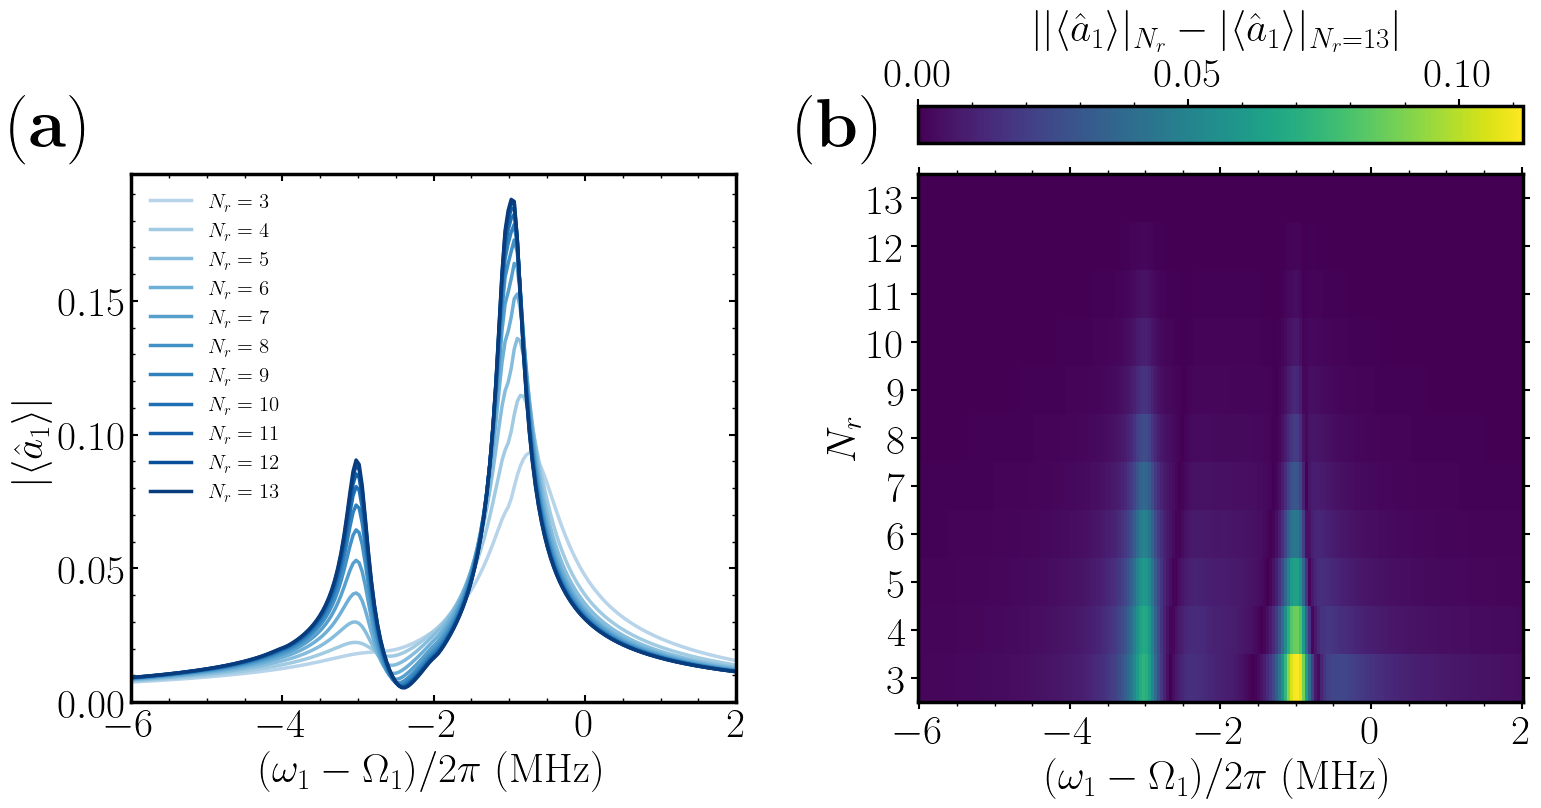

In [178]:
#=====================================================
# Plot
#=====================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Fixed g_a index
i = 0

# One color family, light to dark as N_r increases
cmap = plt.get_cmap("Blues")
colors = cmap(np.linspace(0.30, 0.95, len(Nr_values)))

for color, Nr in zip(colors, Nr_values):
    axes[0].plot(
        x_list_1,
        fieldAmp_A[Nr][i],
        linestyle='-',
        color=color,
        label=rf'$N_r = {Nr}$'
    )

axes[0].set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
axes[0].set_ylabel(r'$\vert\langle \hat{a}_1\rangle\vert$')
axes[0].legend(loc=2)

axes[0].set_xlim(x_list_1.min(), x_list_1.max())
axes[0].set_ylim(0, 1.05 * max(fieldAmp_A[Nr_ref][i, :]))

#=====================================================
# Convergence error heatmap relative to N_r = 13
#=====================================================
i = 0
Nr_ref = 13

ref = fieldAmp_A[Nr_ref][i, :]

error_vs_Nr = np.array([
    np.abs(fieldAmp_A[Nr][i, :] - ref)
    for Nr in Nr_values
])

pcm = axes[1].pcolormesh(
    x_list_1,
    Nr_values,
    error_vs_Nr,
    shading='auto'
)

axes[1].set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
axes[1].set_ylabel(r'$N_r$')
axes[1].set_yticks(Nr_values)

axes[1].xaxis.set_major_locator(MaxNLocator(nbins=5))
axes[1].tick_params(axis='both', which='both', direction='out')
axes[1].tick_params(axis='y', which='minor', left=False, right=False)

#=====================================================
# Top colorbar without changing heatmap frame size
#=====================================================
cax = axes[1].inset_axes([0.0, 1.06, 1.0, 0.07])

cbar = fig.colorbar(
    pcm,
    cax=cax,
    orientation='horizontal'
)

cbar.set_label(
    r'$\left||\langle\hat{a}_1\rangle|_{N_r}-|\langle\hat{a}_1\rangle|_{N_r=13}\right|$',
    labelpad=12
)

cbar.ax.xaxis.set_ticks_position('top')
cbar.ax.xaxis.set_label_position('top')
cbar.ax.tick_params(axis='x', which='both', direction='out')

#=====================================================
# Global spacing
#=====================================================
plt.subplots_adjust(
    left=0.08,
    right=0.95,
    bottom=0.12,
    top=0.78,
    wspace=0.3
)

#=====================================================
# Overlays
#=====================================================
#axes[0].text(-7.5, 0.205, r"$\mathbf{(a)}$", color='black', fontsize=50)
#axes[1].text(-7.5, 14, r"$\mathbf{(b)}$", color='black', fontsize=50)


#=====================================================
# Overlays
#=====================================================
labels = [r'$\mathbf{(a)}$', r'$\mathbf{(b)}$']

for ax, label in zip(axes, labels):
    ax.text(
        -0.2, 1.15, label,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=50,
        color='black'
    )

save_figure(fig,
    folder="Thesis_Figures",
    name="chap4_numerical_convergence_test_part1",
    formats=("pdf", "png"),
    time_stamp=False,
    dpi=300)

plt.show()

## $N_c$ Numerical Convergence Test

In [179]:
#=====================================================
# Files for cavity Hilbert-space convergence
#=====================================================
files_by_Nc = {
    2:  r'Results\Sim0_Convergence_tests_Nc\ResultN22A_[2026-07-06]_[14h06m].npy',
    3:  r'Results\Sim0_Convergence_tests_Nc\ResultN33A_[2026-07-06]_[14h09m].npy',
    4:  r'Results\Sim0_Convergence_tests_Nc\ResultN44A_[2026-07-06]_[13h56m].npy',
}

Nc_values = list(files_by_Nc.keys())

fieldAmp_A = {}
ctime_Nc = []

#=====================================================
# Load and compute |<a_1>|
#=====================================================
for Nc in Nc_values:

    data = load(files_by_Nc[Nc], allow_pickle=True)

    x_list_1 = data[0]        # Delta_a_list
    y_list_1 = data[1]        # galist
    rho_grid = data[2]        # rho_grid[ga_index, Delta_index]

    N_a = int(data[3])
    N_b = int(data[4])
    N_r = int(data[5])
    wr  = data[6]

    ctime_Nc.append(float(data[7]))

    Ny = len(y_list_1)
    Nx = len(x_list_1)

    a_op = tensor(destroy(N_a), qeye(N_b), qeye(N_r))

    field = empty((Ny, Nx), dtype=float)

    for i in range(Ny):
        for j in range(Nx):
            field[i, j] = abs(expect(a_op, rho_grid[i, j]))

    fieldAmp_A[Nc] = field


Saved:
Thesis_Figures\chap4_numerical_convergence_test_part2.pdf
Thesis_Figures\chap4_numerical_convergence_test_part2.png


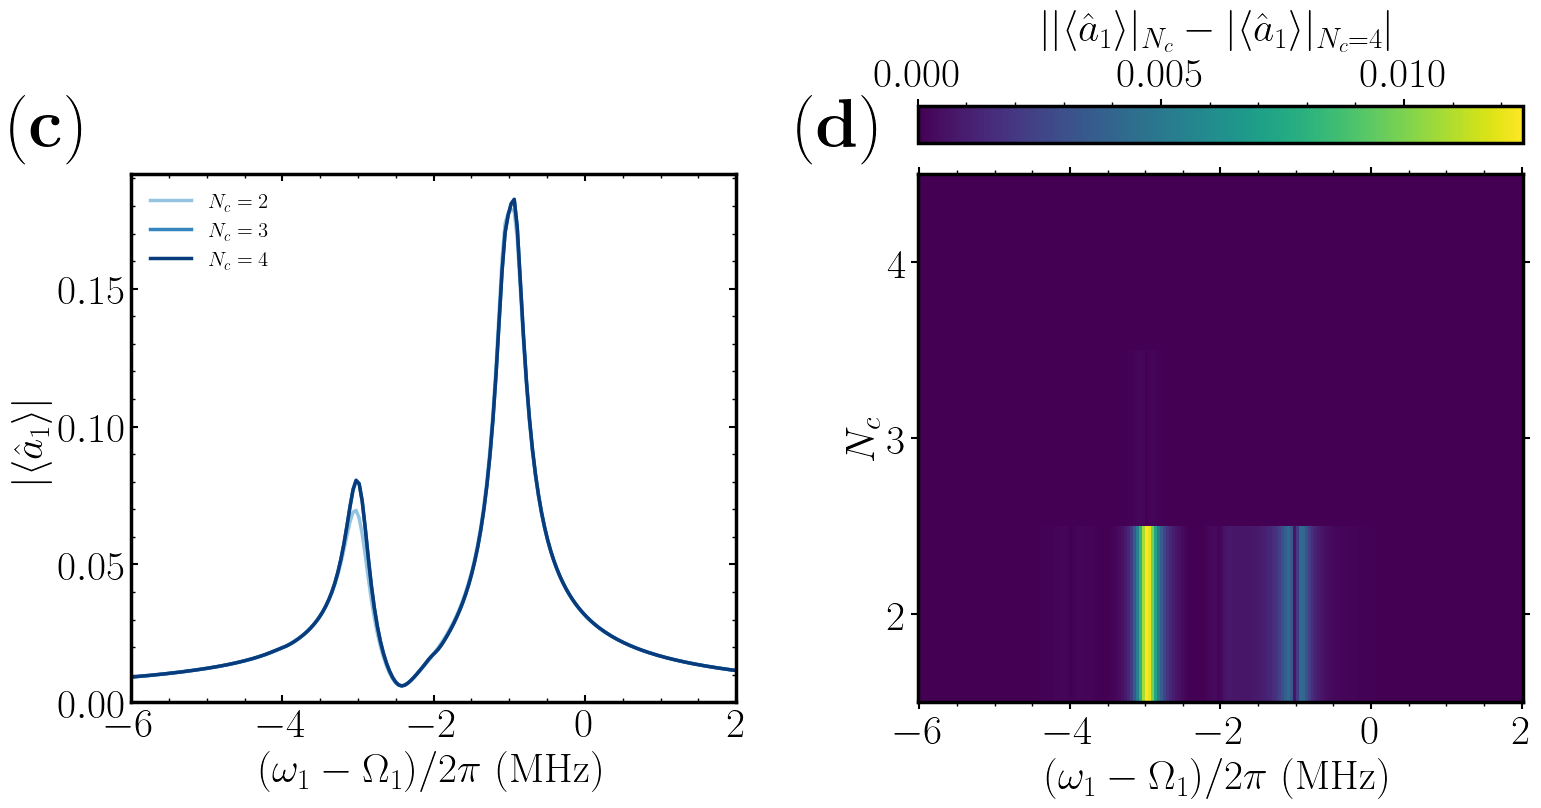

In [180]:
#=====================================================
# Plot
#=====================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Fixed g_a index
i = 0

Nc_ref = max(Nc_values)

# One color family, light to dark as N_c increases
cmap = plt.get_cmap("Blues")
colors = cmap(np.linspace(0.40, 0.95, len(Nc_values)))

for color, Nc in zip(colors, Nc_values):
    axes[0].plot(
        x_list_1,
        fieldAmp_A[Nc][i],
        linestyle='-',
        color=color,
        label=rf'$N_c = {Nc}$'
    )

axes[0].set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
axes[0].set_ylabel(r'$\vert\langle \hat{a}_1\rangle\vert$')
axes[0].set_xlim(x_list_1.min(), x_list_1.max())
axes[0].set_ylim(0, 1.05 * max(fieldAmp_A[Nc_ref][i, :]))
axes[0].legend(loc=2)


#=====================================================
# Convergence error heatmap relative to largest N_c
#=====================================================

ref = fieldAmp_A[Nc_ref][i, :]

error_vs_Nc = np.array([
    np.abs(fieldAmp_A[Nc][i, :] - ref)
    for Nc in Nc_values
])

pcm = axes[1].pcolormesh(
    x_list_1,
    Nc_values,
    error_vs_Nc,
    shading='auto'
)

axes[1].set_xlabel(r'$(\omega_1 - \Omega_1)/2\pi$ (MHz)')
axes[1].set_ylabel(r'$N_c$')

axes[1].set_yticks(Nc_values)
axes[1].xaxis.set_major_locator(MaxNLocator(nbins=5))

axes[1].tick_params(axis='both', which='both', direction='out')
axes[1].tick_params(axis='y', which='minor', left=False, right=False)

#=====================================================
# Top colorbar without changing heatmap frame size
#=====================================================
cax = axes[1].inset_axes([0.0, 1.06, 1.0, 0.07])

cbar = fig.colorbar(
    pcm,
    cax=cax,
    orientation='horizontal'
)

cbar.set_label(
    rf'$\left||\langle\hat{{a}}_1\rangle|_{{N_c}}-|\langle\hat{{a}}_1\rangle|_{{N_c={Nc_ref}}}\right|$',
    labelpad=12
)

cbar.ax.xaxis.set_ticks_position('top')
cbar.ax.xaxis.set_label_position('top')
cbar.ax.tick_params(axis='x', which='both', direction='out')

#=====================================================
# Global spacing
#=====================================================
plt.subplots_adjust(
    left=0.08,
    right=0.95,
    bottom=0.12,
    top=0.78,
    wspace=0.3
)

#=====================================================
# Overlays
#=====================================================
labels = [r'$\mathbf{(c)}$', r'$\mathbf{(d)}$']

for ax, label in zip(axes, labels):
    ax.text(
        -0.2, 1.15, label,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=50,
        color='black'
    )

save_figure(fig,
    folder="Thesis_Figures",
    name="chap4_numerical_convergence_test_part2",
    formats=("pdf", "png"),
    time_stamp=False,
    dpi=300)

plt.show()

## Computation Times


Saved:
Thesis_Figures\chap4_numerical_convergence_test_part3.pdf
Thesis_Figures\chap4_numerical_convergence_test_part3.png


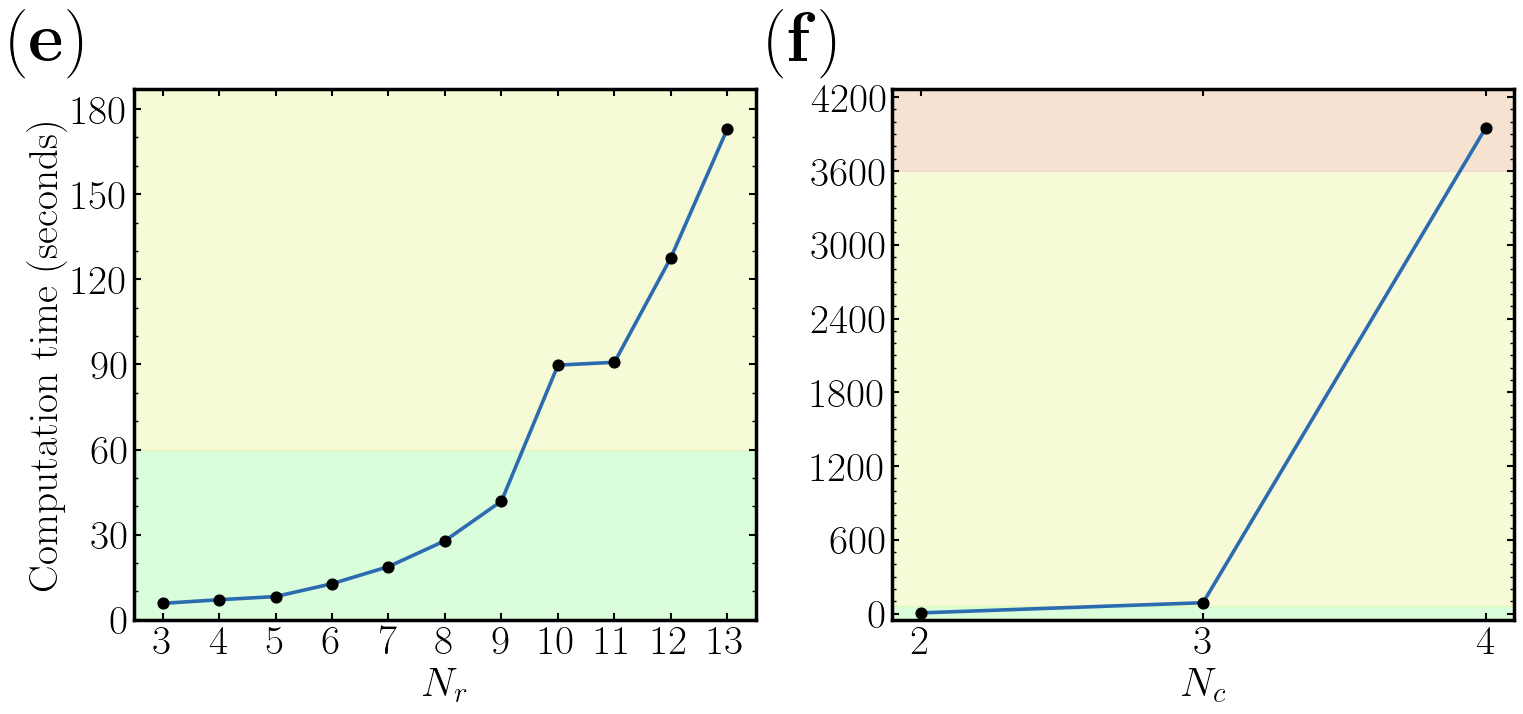

In [181]:
def seconds_formatter(x, pos):
    return f'{x:g}'

def add_time_regions_linear(ax, ymax):
    """
    Linear-scale shaded bands:
      - seconds: 0 to 60 s
      - 1 min+ : 60 s to top
      - 1 h+   : 3600 s to top
    """

    # seconds region
    if ymax > 0:
        ax.axhspan(-50, min(60, ymax), color="#b7fdba", alpha=0.5, zorder=0)

    # 1 minute and above
    if ymax > 60:
        ax.axhspan(60, ymax, color="#f0f7b0", alpha=0.5, zorder=0)

    # 1 hour and above
    if ymax > 3600:
        ax.axhspan(3600, ymax, color='#f5cccc', alpha=0.5, zorder=1)

#=====================================================
# Plot computation times
#=====================================================
fig, axes = plt.subplots(1, 2, figsize=(15.5, 6.8))

line_color = '#2b6cb0'
point_color = 'black'

#=====================================================
# N_r time
#=====================================================
axes[0].plot(Nr_values,ctime_Nr,
             linestyle='-',
             linewidth=2.6,
             color=line_color,
             zorder=2)
axes[0].scatter(Nr_values,ctime_Nr,
                s=60,
                color=point_color,
                zorder=3)

axes[0].set_xlabel(r'$N_r$')
axes[0].set_ylabel(r'Computation time (seconds)')

# show all integer ticks from 3 to 13
axes[0].set_xticks(Nr_values)

ymax0 = 1.08 * max(ctime_Nr)
axes[0].set_ylim(0, ymax0)

add_time_regions_linear(axes[0], ymax0)

axes[0].yaxis.set_major_locator(MaxNLocator(nbins=7))
axes[0].yaxis.set_major_formatter(FuncFormatter(seconds_formatter))
axes[0].yaxis.set_minor_locator(AutoMinorLocator(3))
axes[0].tick_params(axis='both', which='both', direction='in')
axes[0].tick_params(axis='x', which='minor', bottom=False, top=False)

#=====================================================
# N_c time
#=====================================================
axes[1].plot(Nc_values,ctime_Nc,
             linestyle='-',
             linewidth=2.6,
             color=line_color,
             zorder=2
)

axes[1].scatter(Nc_values,ctime_Nc,
                s=60,
                color=point_color,
                zorder=3
)

axes[1].set_xlabel(r'$N_c$')
axes[1].set_ylabel('')

axes[1].set_xticks(Nc_values)

ymax1 = 1.08 * max(ctime_Nc)
axes[1].set_ylim(-50, ymax1)

add_time_regions_linear(axes[1], ymax1)

axes[1].yaxis.set_major_locator(MaxNLocator(nbins=8))
axes[1].yaxis.set_major_formatter(FuncFormatter(seconds_formatter))
axes[1].yaxis.set_minor_locator(AutoMinorLocator(6))
axes[1].tick_params(axis='both', which='both', direction='in')
axes[1].tick_params(axis='x', which='minor', bottom=False, top=False)

#=====================================================
# Global spacing
#=====================================================
plt.subplots_adjust(
    left=0.09,
    right=0.98,
    bottom=0.17,
    top=0.95,
    wspace=0.22
)

#=====================================================
# Overlays
#=====================================================
labels = [r'$\mathbf{(e)}$', r'$\mathbf{(f)}$']

for ax, label in zip(axes, labels):
    ax.text(
        -0.2, 1.15, label,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=50,
        color='black'
    )

save_figure(fig,
    folder="Thesis_Figures",
    name="chap4_numerical_convergence_test_part3",
    formats=("pdf", "png"),
    time_stamp=False,
    dpi=300)

plt.show()

## Photon Blockade Demonstration

In [182]:
#=====================================================
# Load data (E_a = E_b = 30 kHz)
#=====================================================
data_block = load(r'Results\Sim0_Photon_blockade\PhotonBlockade_[2026-07-08]_[14h00m].npy',
                  allow_pickle=True)

data_cross = load(r'Results\Sim0_Photon_blockade\CrossBlockade_[2026-07-08]_[14h49m].npy',
                  allow_pickle=True)

ga_list_block = array(data_block[0], dtype=float)
gb_list_block = array(data_block[1], dtype=float)
rho_grid_block = data_block[2]

N_a_block = int(data_block[3])
N_b_block = int(data_block[4])
N_r_block = int(data_block[5])
wr_block  = float(data_block[6])

ga_list_cross = array(data_cross[0], dtype=float)
gb_list_cross = array(data_cross[1], dtype=float)
rho_grid_cross = data_cross[2]

N_a_cross = int(data_cross[3])
N_b_cross = int(data_cross[4])
N_r_cross = int(data_cross[5])
wr_cross  = float(data_cross[6])

#=====================================================
# Parameters used in the thresholds
#=====================================================
kappa_a = 0.08   # MHz
eps = 1e-15

#=====================================================
# Operators
#=====================================================
a_block = tensor(destroy(N_a_block), qeye(N_b_block), qeye(N_r_block))
b_block = tensor(qeye(N_a_block), destroy(N_b_block), qeye(N_r_block))
Na_block = a_block.dag() * a_block
Nb_block = b_block.dag() * b_block

a_cross = tensor(destroy(N_a_cross), qeye(N_b_cross), qeye(N_r_cross))
b_cross = tensor(qeye(N_a_cross), destroy(N_b_cross), qeye(N_r_cross))
Na_cross = a_cross.dag() * a_cross
Nb_cross = b_cross.dag() * b_cross

def idx_AB(na, nb, N_b):
    return na * N_b + nb

#=====================================================
# Self-blockade: gb = 0
#=====================================================
i_gb0 = argmin(abs(gb_list_block - 0.0))

n_pop_plot = min(N_a_block, 5)   # P0, P1, P2, P3, P4
P_block = zeros((n_pop_plot, len(ga_list_block)))
g2a_block = zeros(len(ga_list_block))

for j, ga in enumerate(ga_list_block):
    rho_ss = rho_grid_block[i_gb0, j]

    rhoA = ptrace(rho_ss, 0)
    diagA = real(rhoA.diag())

    for n in range(n_pop_plot):
        P_block[n, j] = diagA[n]

    na_exp = real(expect(Na_block, rho_ss))
    n2_exp = real(expect(a_block.dag() * a_block.dag() * a_block * a_block, rho_ss))

    if na_exp > 1e-12:
        g2a_block[j] = n2_exp / (na_exp**2)
    else:
        g2a_block[j] = nan

#=====================================================
# Cross-blockade: use last ga value, sweep gb
#=====================================================
j_ga_fixed = -1
ga_fixed = ga_list_cross[j_ga_fixed]

print(f"Using ga = {ga_fixed:.3f} MHz")

P10 = zeros(len(gb_list_cross))
P01 = zeros(len(gb_list_cross))
P11 = zeros(len(gb_list_cross))
g2ab_cross = zeros(len(gb_list_cross))

for i, gb in enumerate(gb_list_cross):

    rho_ss = rho_grid_cross[i, j_ga_fixed]

    rhoAB = ptrace(rho_ss, (0, 1))
    diagAB = real(rhoAB.diag())

    P10[i] = diagAB[idx_AB(1, 0, N_b_cross)]
    P01[i] = diagAB[idx_AB(0, 1, N_b_cross)]
    P11[i] = diagAB[idx_AB(1, 1, N_b_cross)]

    na_exp = real(expect(Na_cross, rho_ss))
    nb_exp = real(expect(Nb_cross, rho_ss))
    nanb_exp = real(expect(Na_cross * Nb_cross, rho_ss))

    denom = na_exp * nb_exp

    if denom > 1e-12:
        g2ab_cross[i] = nanb_exp / denom
    else:
        g2ab_cross[i] = nan

#=====================================================
# Thresholds
#=====================================================
g_self_th = sqrt(kappa_a * wr_block / 2.0)

g_cross_th = kappa_a * wr_cross / (2.0 * ga_fixed)

print("Self-blockade threshold ga =", g_self_th, "MHz")
print(f"Cross-blockade threshold gb = {g_cross_th:.3f} MHz")

Using ga = 3.000 MHz
Self-blockade threshold ga = 2.0 MHz
Cross-blockade threshold gb = 1.333 MHz



Saved:
Thesis_Figures\chap4_photon_blockade_2x2_regions_[2026-07-29]_[15h42m].pdf


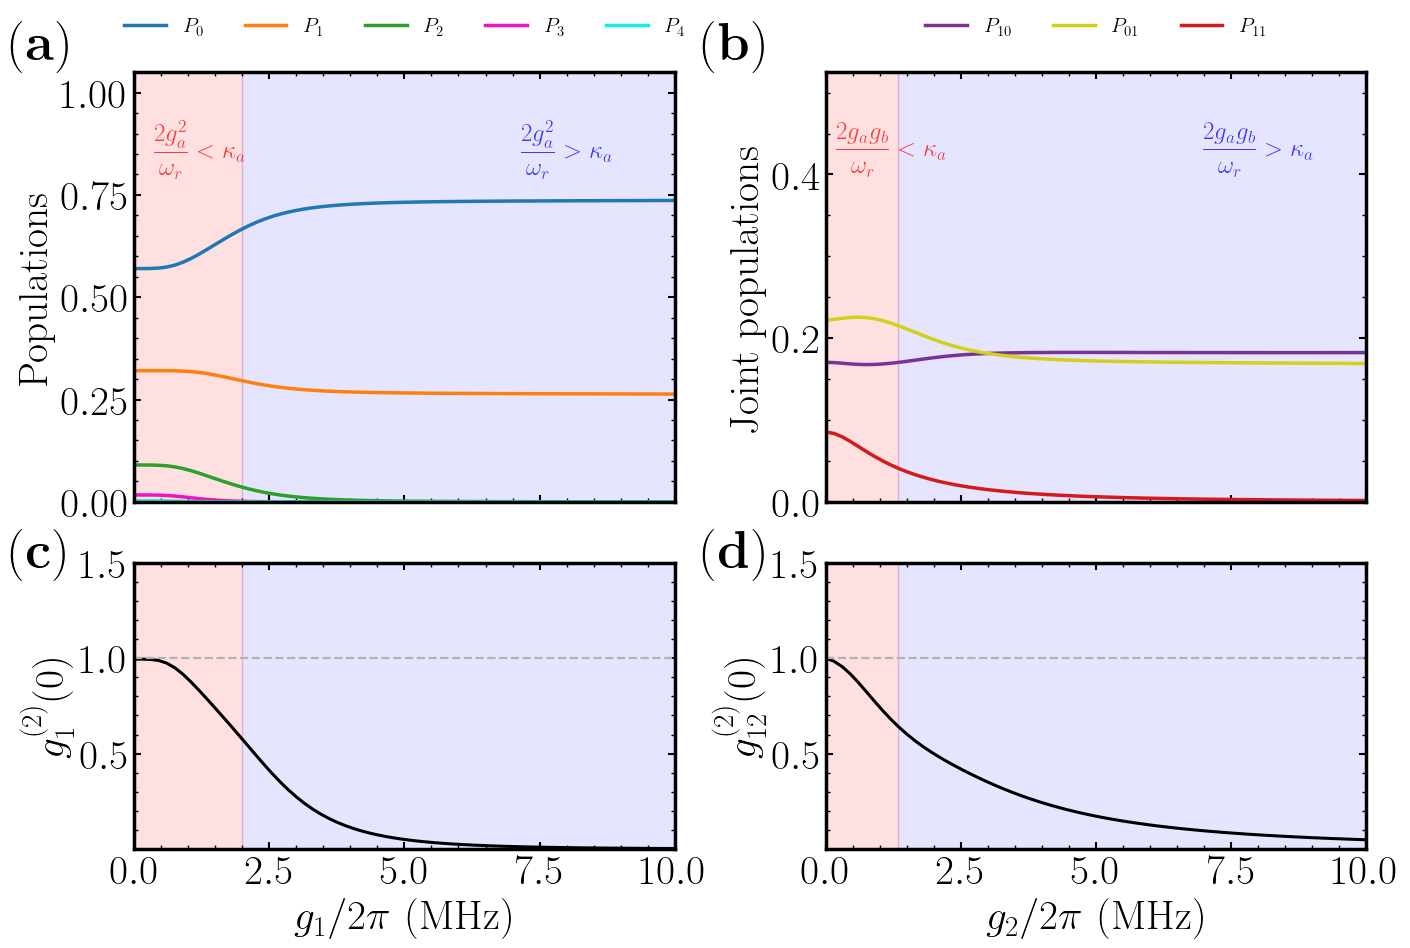

In [184]:
#=====================================================
# Helper: shaded blockade regions
#=====================================================
def add_blockade_regions(ax, x_min, x_max, x_th, left_text, right_text):
    # weak/unresolved region
    ax.axvspan(x_min, min(x_th, x_max), color='red', alpha=0.12, zorder=0)

    # strong/resolved region
    if x_th < x_max:
        ax.axvspan(max(x_th, x_min), x_max, color='blue', alpha=0.10, zorder=0)

    # threshold line
    #ax.axvline(x_th, linestyle='--', color='gray', linewidth=1.5, zorder=1)

    # labels
    ax.text( 0.12, 0.82, 
            left_text,
            transform=ax.transAxes,
            color='red',
            fontsize=18,
            ha='center',
            va='center',
            alpha=0.75
    )

    ax.text(0.80, 0.82, 
            right_text,
            transform=ax.transAxes,
            color='blue',
            fontsize=18,
            ha='center',
            va='center',
            alpha=0.75
    )

colors_self = ['#1f77b4', '#ff7f0e', '#2ca02c']   # left/top plot
colors_cross = ['#7b3294', '#008837', '#d7191c']  # right/top plot

#=====================================================
# Plot
#=====================================================
fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10.5),
    sharex='col',
    gridspec_kw={'height_ratios': [3, 2], 'hspace': 0.17, 'wspace': 0.28}
)

#-----------------------------------------------------
# Top-left: self-blockade populations
#-----------------------------------------------------
add_blockade_regions(
    axes[0, 0],
    ga_list_block[0], ga_list_block[-1], g_self_th,
    left_text=rf'$\displaystyle\frac{{2g_a^2}}{{\omega_r}} < \kappa_a$',
    right_text=rf'$\displaystyle\frac{{2g_a^2}}{{\omega_r}} > \kappa_a$'
)

colors_left = ['#1f77b4', '#ff7f0e', '#2ca02c',"#f013c0","#13f0de"]
labels_left = [r'$P_0$', r'$P_1$', r'$P_2$', r'$P_3$', r'$P_4$']

for n in range(n_pop_plot):
    axes[0, 0].plot(
        ga_list_block,
        P_block[n],
        linewidth=2.5,
        color=colors_left[n],
        label=labels_left[n]
    )

axes[0, 0].set_ylabel(r'Populations')
axes[0, 0].set_ylim(0, 1.05)
axes[0, 0].set_xlim(ga_list_block[0], 10)
axes[0, 0].tick_params(axis='both', which='both', direction='in', labelbottom=False)

#-----------------------------------------------------
# Bottom-left: g2 self-blockade
#-----------------------------------------------------
add_blockade_regions(
    axes[1, 0],
    ga_list_block[0], ga_list_block[-1], g_self_th,
    left_text='',
    right_text=''
)

axes[1, 0].plot(
    ga_list_block,
    g2a_block,
    color='black',
    linewidth=2.2
)

axes[1, 0].axhline(1.0, linestyle='--', color='0.7', linewidth=1.6)

axes[1, 0].set_xlabel(r'$g_1/2\pi$ (MHz)')
axes[1, 0].set_ylabel(r'$g_1^{(2)}(0)$')
axes[1, 0].set_ylim(0.00001, 1.5)
axes[1, 0].set_xlim(0,10)
axes[1, 0].tick_params(axis='both', which='both', direction='in')

#-----------------------------------------------------
# Top-right: cross-blockade joint populations
#-----------------------------------------------------
add_blockade_regions(
    axes[0, 1],
    gb_list_cross[0], gb_list_cross[-1], g_cross_th,
    left_text=rf'$\displaystyle\frac{{2g_ag_b}}{{\omega_r}} < \kappa_a$',
    right_text=rf'$\displaystyle\frac{{2g_ag_b}}{{\omega_r}} > \kappa_a$'
)

colors_right = ['#7b3294', "#D3D01A", '#d7191c']

axes[0, 1].plot(gb_list_cross, P10, linewidth=2.5, color=colors_right[0], label=r'$P_{10}$')
axes[0, 1].plot(gb_list_cross, P01, linewidth=2.5, color=colors_right[1], label=r'$P_{01}$')
axes[0, 1].plot(gb_list_cross, P11, linewidth=2.5, color=colors_right[2], label=r'$P_{11}$')

axes[0, 1].set_ylabel(r'Joint populations')
axes[0, 1].set_ylim(0, 0.5 * 1.05)
axes[0, 1].set_xlim(gb_list_cross[0], 10)
axes[0, 1].tick_params(axis='both', which='both', direction='in', labelbottom=False)

#-----------------------------------------------------
# Bottom-right: cross-correlation
#-----------------------------------------------------
add_blockade_regions(
    axes[1, 1],
    gb_list_cross[0], gb_list_cross[-1], g_cross_th,
    left_text='',
    right_text=''
)

axes[1, 1].plot(gb_list_cross,g2ab_cross,
                color='black',
                linewidth=2.2)

axes[1, 1].axhline(1.0, linestyle='--', color='0.7', linewidth=1.6)

axes[1, 1].set_xlabel(r'$g_2/2\pi$ (MHz)')
axes[1, 1].set_ylabel(r'$g_{12}^{(2)}(0)$')
axes[1, 1].set_ylim(0.00001, 1.5)
axes[1, 1].set_xlim(0, 10)
axes[1, 1].tick_params(axis='both', which='both', direction='in')


#=====================================================
# Separate legends outside, on top of each plot
#=====================================================
handles_left, labels_left = axes[0, 0].get_legend_handles_labels()
handles_right, labels_right = axes[0, 1].get_legend_handles_labels()

axes[0, 0].legend(
    handles_left,
    labels_left,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.04),
    ncol=5,
    frameon=False
)

axes[0, 1].legend(
    handles_right,
    labels_right,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.04),
    ncol=3,
    frameon=False
)

#=====================================================
# Overlays
#=====================================================
panel_labels = [r'$\mathbf{(a)}$', r'$\mathbf{(b)}$', r'$\mathbf{(c)}$', r'$\mathbf{(d)}$']

for ax, label in zip(axes.flat, panel_labels):
    ax.text(
        -0.23, 1.12,
        label,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=38,
        color='black'
    )

#=====================================================
# Spacing
#=====================================================
plt.subplots_adjust(
    left=0.09,
    right=0.97,
    bottom=0.10,
    top=0.84,
    wspace=0.28,
    hspace=0.06
)

save_figure(fig, 'Thesis_Figures', "chap4_photon_blockade_2x2_regions", formats=["pdf"])
plt.show()

## Temperature Influence on Blockade Populations

In [185]:
#=====================================================
# Load data (E_a = E_b = 30 kHz)
#=====================================================
data_block_0K = load(r'Results\Sim0_Photon_blockade\PhotonBlockade_0K_[2026-07-15]_[01h30m].npy',
                     allow_pickle=True
)

data_cross_0K = load(r'Results\Sim0_Photon_blockade\CrossBlockade_[2026-07-08]_[14h50m].npy',
                     allow_pickle=True
)

data_block_10mK = load(r'Results\Sim0_Photon_blockade\PhotonBlockade_10mK_[2026-07-15]_[00h54m].npy',
                       allow_pickle=True
)

data_cross_10mK = load(r'Results\Sim0_Photon_blockade\CrossBlockade_10mK_[2026-07-15]_[00h30m].npy',
                       allow_pickle=True
)
#=====================================================
# Helper: unpack stored data
#=====================================================
def unpack_data(data):

    x_list = array(data[0], dtype=float)
    y_list = array(data[1], dtype=float)
    rho_grid = data[2]

    N_a = int(data[3])
    N_b = int(data[4])
    N_r = int(data[5])
    wr  = float(data[6])

    return x_list, y_list, rho_grid, N_a, N_b, N_r, wr

#=====================================================
# Unpack self-blockade data
#=====================================================
(
    ga_list_block_0K,
    gb_list_block_0K,
    rho_grid_block_0K,
    N_a_block_0K,
    N_b_block_0K,
    N_r_block_0K,
    wr_block_0K
) = unpack_data(data_block_0K)

(
    ga_list_block_10mK,
    gb_list_block_10mK,
    rho_grid_block_10mK,
    N_a_block_10mK,
    N_b_block_10mK,
    N_r_block_10mK,
    wr_block_10mK
) = unpack_data(data_block_10mK)

#=====================================================
# Unpack cross-blockade data
#=====================================================
(
    ga_list_cross_0K,
    gb_list_cross_0K,
    rho_grid_cross_0K,
    N_a_cross_0K,
    N_b_cross_0K,
    N_r_cross_0K,
    wr_cross_0K
) = unpack_data(data_cross_0K)

(
    ga_list_cross_10mK,
    gb_list_cross_10mK,
    rho_grid_cross_10mK,
    N_a_cross_10mK,
    N_b_cross_10mK,
    N_r_cross_10mK,
    wr_cross_10mK
) = unpack_data(data_cross_10mK)

#=====================================================
# Parameters used in blockade thresholds
#=====================================================
kappa_a = 0.08   # MHz
#=====================================================
# Joint density-matrix index
#=====================================================
def idx_AB(na, nb, N_b):

    return na * N_b + nb
#=====================================================
# Helper: extract P1 for self-blockade
#=====================================================
def extract_P1(
    ga_list,
    gb_list,
    rho_grid
):

    i_gb0 = argmin(abs(gb_list - 0.0))

    P1 = zeros(len(ga_list))
    P2 = zeros(len(ga_list))

    for j, ga in enumerate(ga_list):

        rho_ss = rho_grid[i_gb0, j]

        rhoA = ptrace(rho_ss, 0)
        diagA = real(rhoA.diag())

        P1[j] = diagA[1]
        P2[j] = diagA[2]

    return P1, P2
#=====================================================
# Self-blockade populations
#=====================================================
P1_block_0K, P2_block_0K  = extract_P1(ga_list_block_0K,gb_list_block_0K,rho_grid_block_0K)

P1_block_10mK, P2_block_10mK = extract_P1(ga_list_block_10mK,gb_list_block_10mK,rho_grid_block_10mK)
#=====================================================
# Helper: extract P10 and P01 for cross-blockade
#=====================================================
def extract_joint_populations(
    ga_list,
    gb_list,
    rho_grid,
    N_b,
    ga_fixed_target
):

    j_ga_fixed = argmin(abs(ga_list - ga_fixed_target))
    ga_fixed = ga_list[j_ga_fixed]

    P10 = zeros(len(gb_list))
    P01 = zeros(len(gb_list))
    P11 = zeros(len(gb_list))

    for i, gb in enumerate(gb_list):

        rho_ss = rho_grid[i, j_ga_fixed]

        rhoAB = ptrace(rho_ss, (0, 1))
        diagAB = real(rhoAB.diag())

        P10[i] = diagAB[idx_AB(1, 0, N_b)]
        P01[i] = diagAB[idx_AB(0, 1, N_b)]
        P11[i] = diagAB[idx_AB(1, 1, N_b)]

    return P10, P01, P11, ga_fixed

#=====================================================
# Cross-blockade populations
#=====================================================
# Fixed value of g_a used for the cross-blockade comparison.
ga_fixed_target = 3.0   # MHz

P10_cross_0K, P01_cross_0K, P11_cross_0K, ga_fixed_0K = extract_joint_populations(ga_list_cross_0K,
                                                                                  gb_list_cross_0K,
                                                                                  rho_grid_cross_0K,
                                                                                  N_b_cross_0K,
                                                                                  ga_fixed_target)

P10_cross_10mK, P01_cross_10mK, P11_cross_10mK, ga_fixed_10mK = extract_joint_populations(ga_list_cross_10mK,
                                                                                          gb_list_cross_10mK,
                                                                                          rho_grid_cross_10mK,
                                                                                          N_b_cross_10mK,
                                                                                          ga_fixed_target)
print(f"Using ga = {ga_fixed_0K:.3f} MHz for T = 0 K")
print(f"Using ga = {ga_fixed_10mK:.3f} MHz for T = 10 mK")
#=====================================================
# Thresholds
#=====================================================
g_self_th = sqrt(kappa_a * wr_block_0K / 2.0)
g_cross_th = (kappa_a * wr_cross_0K / (2.0 * ga_fixed_0K))

print(f"Self-blockade threshold ga = {g_self_th:.3f} MHz")
print(f"Cross-blockade threshold gb = {g_cross_th:.3f} MHz")

Using ga = 3.000 MHz for T = 0 K
Using ga = 3.000 MHz for T = 10 mK
Self-blockade threshold ga = 2.000 MHz
Cross-blockade threshold gb = 1.333 MHz



Saved:
Thesis_Figures\chap4_photon_blockade_temperature_populations_[2026-07-29]_[15h44m].pdf


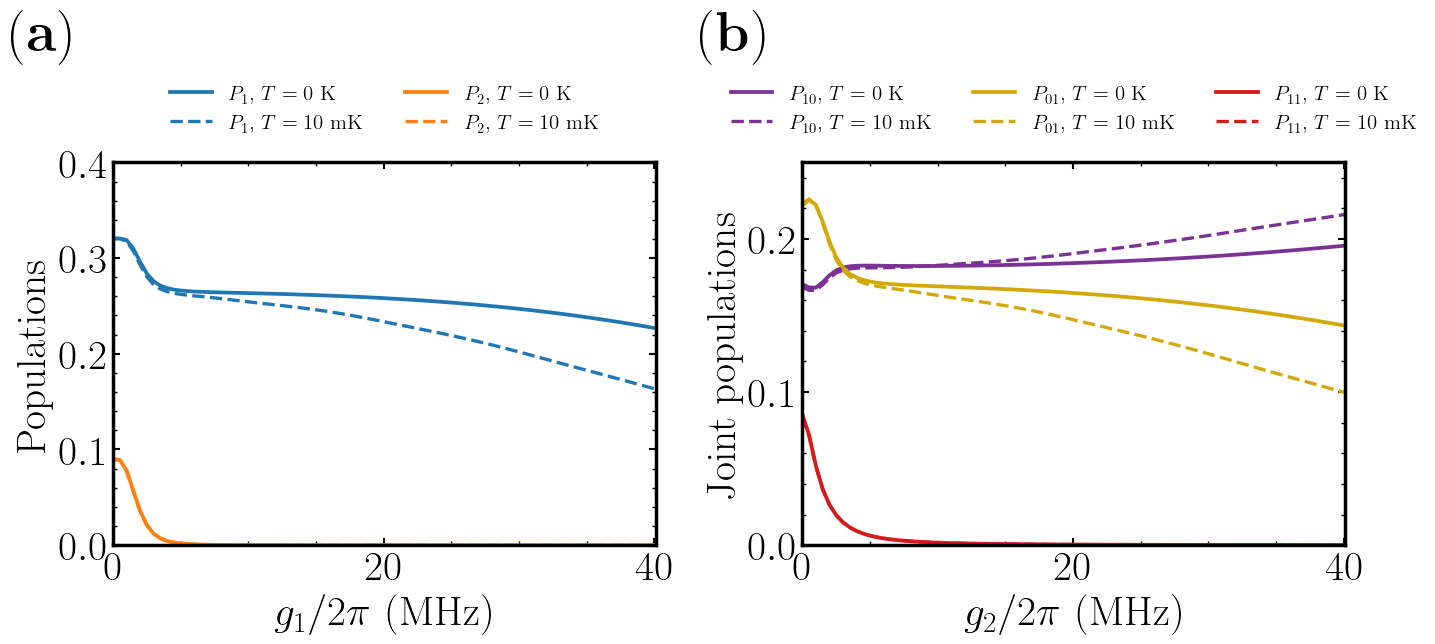

In [186]:
#=====================================================
# Plot settings
#=====================================================
ga_plot_max = min(10.0,ga_list_block_0K[-1],ga_list_block_10mK[-1])
gb_plot_max = min(10.0,gb_list_cross_0K[-1],gb_list_cross_10mK[-1])

color_P1  = '#1f77b4'
color_P10 = '#7b3294'
color_P01 = '#D3A90A'
color_P2  = '#ff7f0e'
color_P11 = '#d7191c'

linewidth_0K   = 2.7
linewidth_10mK = 2.4
#=====================================================
# Create figure
#=====================================================
fig, axes = plt.subplots(1,2,figsize=(14, 5.8),sharey=False,gridspec_kw={'wspace': 0.27})
#-----------------------------------------------------
# Left: self-blockade P1 population
#-----------------------------------------------------
axes[0].plot(ga_list_block_0K,P1_block_0K,
             linewidth=linewidth_0K,
             linestyle='-',
             color=color_P1,
             label=r'$P_{1}$, $T=0\ \mathrm{K}$')

axes[0].plot(ga_list_block_10mK,P1_block_10mK,
             linewidth=linewidth_10mK,
             linestyle='--',
             color=color_P1,
             label=r'$P_{1}$, $T=10\ \mathrm{mK}$')

axes[0].plot(ga_list_block_0K,P2_block_0K,
             linewidth=linewidth_0K,
             linestyle='-',
             color=color_P2,
             label=r'$P_{2}$, $T=0\ \mathrm{K}$')

axes[0].plot(ga_list_block_10mK,P2_block_10mK,
             linewidth=linewidth_10mK,
             linestyle='--',
             color=color_P2,
             label=r'$P_{2}$, $T=10\ \mathrm{mK}$')

axes[0].set_xlabel(r'$g_1/2\pi$ (MHz)')
axes[0].set_ylabel(r'Populations')
axes[0].set_xlim(0,40.1)
axes[0].set_ylim(0., 0.4)

axes[0].tick_params(axis='both',which='both',direction='in')

axes[0].legend(loc='lower center',bbox_to_anchor=(0.5, 1.03),ncol=2,frameon=False)
#-----------------------------------------------------
# Right: cross-blockade P10 and P01 populations
#-----------------------------------------------------
# P10, T = 0 K
axes[1].plot(gb_list_cross_0K,P10_cross_0K,
             linewidth=linewidth_0K,
             linestyle='-',
             color=color_P10,
             label=r'$P_{10}$, $T=0\ \mathrm{K}$')

# P10, T = 10 mK
axes[1].plot(gb_list_cross_10mK,P10_cross_10mK,
             linewidth=linewidth_10mK,
             linestyle='--',
             color=color_P10,
             label=r'$P_{10}$, $T=10\ \mathrm{mK}$')

# P01, T = 0 K
axes[1].plot(gb_list_cross_0K,P01_cross_0K,
             linewidth=linewidth_0K,
             linestyle='-',
             color=color_P01,
             label=r'$P_{01}$, $T=0\ \mathrm{K}$')

# P01, T = 10 mK
axes[1].plot(gb_list_cross_10mK,P01_cross_10mK,
             linewidth=linewidth_10mK,
             linestyle='--',
             color=color_P01,
             label=r'$P_{01}$, $T=10\ \mathrm{mK}$')

# P11, T = 0 K
axes[1].plot(gb_list_cross_0K,P11_cross_0K,
             linewidth=linewidth_0K,
             linestyle='-',
             color=color_P11,
             label=r'$P_{11}$, $T=0\ \mathrm{K}$')

# P11, T = 10 mK
axes[1].plot(gb_list_cross_10mK,P11_cross_10mK,
             linewidth=linewidth_10mK,
             linestyle='--',
             color=color_P11,
             label=r'$P_{11}$, $T=10\ \mathrm{mK}$')

axes[1].set_xlabel(r'$g_2/2\pi$ (MHz)')
axes[1].set_ylabel(r'Joint populations')

axes[1].set_xlim(0, 40.1)
axes[1].set_ylim(0.0, 0.25)

axes[1].tick_params(axis='both',which='both',direction='in')
axes[1].legend(loc='lower center',bbox_to_anchor=(0.5, 1.03),ncol=3,frameon=False)
#=====================================================
# Panel labels
#=====================================================
panel_labels = [r'$\mathbf{(a)}$',r'$\mathbf{(b)}$']

for ax, label in zip(axes, panel_labels):

    ax.text(
        -0.19,
        1.4,
        label,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=40,
        color='black'
    )
#=====================================================
# Spacing and saving
#=====================================================
plt.subplots_adjust(
    left=0.09,
    right=0.97,
    bottom=0.14,
    top=0.80,
    wspace=0.27
)

save_figure(fig,'Thesis_Figures','chap4_photon_blockade_temperature_populations',formats=['pdf'])

plt.show()